# Crypt analysis

In this notebook we automatically segment crypts from villi in the pre-processed organoids. The algorithm is generally quite robust against false positives but does miss crypts where either the crypt- or neck curvature does not deviate significantly from the rest of the organoid. Next, the crypts are analysed, particularly in regards to their marker composition. 

In [1]:
from src.OrganoidMesh import OrganoidMesh
from src.mesh_analysis import *
from src.nonlocal_correlations import *
from src.cell_graph_functions import *
from src.utils import *
from src.crypt_extraction import *
from src.organoid_plotting import *
from src.cell_graph_functions import positive_indices_and_labels

## Load preprocessed data and run crypt segmentation

In [2]:
def _to_patch_list(x):
    """Normalize to list[set[int]]: None -> [], set -> [set], list/tuple -> list of sets."""
    if x is None:
        return []
    if isinstance(x, set):
        return [x]
    if isinstance(x, (list, tuple)):
        return [set(p) for p in x if p is not None and len(p) > 0]
    # anything else: ignore
    return []

In [ ]:
import pandas as pd
import numpy as np
import os, glob
from tqdm import tqdm


BLACKLIST = { # Organoids with interior nodes
    "day3p5_B03_10",
    "day4p5_B06_48",
    "day4p5-more_C01_5",
    "day4p5-more_C01_78",
    "day4p5-more_C02_27",
    "day4p5-more_C02_26",
    "day4p5-more_C02_35",
    "day4p5-more_C02_85",
    "day4p5-more_C02_88",
    "day4p5-more_C02_94",
    "day4p5-more_C02_127",
    "day4p5-more_C03_11",
    "day4p5-more_C03_17",
    "day4p5-more_C03_19",
    "day4p5-more_C03_45",
    "day4p5-more_C03_90",
    "day4p5-more_C03_96",
    "day4p5-more_C03_112",
    "day4p5-more_C03_137",
    "day4p5-more_C03_142",
    "day4p5-more_C04_14",
    "day4p5-more_C04_16",
    "day4p5-more_C04_22",
    "day4p5-more_C04_109",
    "day4p5-more_C05_127",
    "day4p5-more_C05_131",
    "day4p5-more_C05_142",
    "day4p5-more_C05_143",
    # the next are from Irene
    'day4p5-more_C01_138',
    'day4p5-more_C01_37', 
    'day4p5-more_C01_5',
    'day4p5-more_C01_53', 
    'day4p5-more_C01_78', 
    'day4p5-more_C01_93',
    'day4p5-more_C01_94', 
    'day4p5-more_C02_103', 
    'day4p5-more_C02_105',
    'day4p5-more_C02_127',
    'day4p5-more_C02_27',
    'day4p5-more_C02_35',
    'day4p5-more_C02_61',
    'day4p5-more_C02_77',
    'day4p5-more_C02_78',
    'day4p5-more_C02_85',
    'day4p5-more_C02_88',
    'day4p5-more_C02_94',
    'day4p5-more_C03_11',
    'day4p5-more_C03_110',
    'day4p5-more_C03_112',
    'day4p5-more_C03_135',
    'day4p5-more_C03_14',
    'day4p5-more_C03_149',
    'day4p5-more_C03_150',
    'day4p5-more_C03_152',
    'day4p5-more_C03_161',
    'day4p5-more_C03_166',
    'day4p5-more_C03_17',
    'day4p5-more_C03_171',
    'day4p5-more_C03_19',
    'day4p5-more_C03_30',
    'day4p5-more_C03_45',
    'day4p5-more_C03_60',
    'day4p5-more_C03_62',
    'day4p5-more_C03_64',
    'day4p5-more_C03_72',
    'day4p5-more_C03_86',
    'day4p5-more_C03_90',
    'day4p5-more_C03_96',
    'day4p5-more_C03_97',
    'day4p5-more_C04_109',
    'day4p5-more_C04_125',
    'day4p5-more_C04_132',
    'day4p5-more_C04_14',
    'day4p5-more_C04_16',
    'day4p5-more_C04_19',
    'day4p5-more_C04_22',
    'day4p5-more_C04_27',
    'day4p5-more_C04_30',
    'day4p5-more_C04_53',    
    'day4p5-more_C04_63', 
    'day4p5-more_C04_70', 
    'day4p5-more_C04_74',
    'day4p5-more_C04_75', 
    'day4p5-more_C04_76', 
    'day4p5-more_C04_80',
    'day4p5-more_C04_96', 
    'day4p5-more_C04_99', 
    'day4p5-more_C05_109',
    'day4p5-more_C05_127', 
    'day4p5-more_C05_131', 
    'day4p5-more_C05_142',
    'day4p5-more_C05_143', 
    'day4p5-more_C05_152', 
    'day4p5-more_C05_21',
    'day4p5-more_C05_4', 
    'day4p5-more_C05_42', 
    'day4p5-more_C05_43',
    'day4p5-more_C05_65', 
    'day4p5-more_C05_67', 
    'day4p5-more_C05_80',
    'day4p5-more_C05_82', 
    'day4p5-more_C05_94', 
    'day4p5-more_C06_100',
    'day4p5-more_C06_139', 
    'day4p5-more_C06_140', 
    'day4p5-more_C06_156',
    'day4p5-more_C06_166', 
    'day4p5-more_C06_175', 
    'day4p5-more_C06_177',
    'day4p5-more_C06_180',
}


marker_names = ['LGR5', 'Chromogranin A', 'Cyclin D', 'Mucin 2', 'AldoB',
                'Glucagon', 'Cyclin A', 'Agr2', 'Serotonin', 'Lysozyme']


# -----------------------------------------
# Load complexity scores from tsne_results.csv
# -----------------------------------------
tsne_df = pd.read_csv("../NicoleData/tsne_results.csv")
complexity_dict = dict(zip(tsne_df["label_uid"], tsne_df["complexity"]))
print(f"Loaded {len(complexity_dict)} complexity scores")

# Base directory for preprocessed data
preproc_base = os.path.join('..', 'NicoleData', 'graphs')

# --- Discover available timepoints dynamically ---
timepoints = sorted(
    [d for d in os.listdir(preproc_base) if os.path.isdir(os.path.join(preproc_base, d))]
)
print(f"Found {len(timepoints)} timepoints: {timepoints}")

# timepoints = timepoints[3:] # KEEP ONLY FROM day3p5 ONWARDS
timepoints = [timepoints[6]] # KEEP ONLY day4p5
# timepoints = timepoints[4:] # KEEP ONLY FROM day4 ONWARDS


# --- Initialize container ---
results = {}

for tp in timepoints:
    print(f"\n=== Processing timepoint: {tp} ===")

    tp_dir = os.path.join(preproc_base, tp)
    gpickle_files = sorted(glob.glob(os.path.join(tp_dir, "*.gpickle")))
    if not gpickle_files:
        print(f"  ⚠ No .gpickle files found for {tp}, skipping.")
        continue

    # Per-timepoint storage
    complexity_list = []
    label_uid_list = []
    crypt_list = []
    villus_list = []
    neck_list = []
    cell_graphs_list = []

    dropped_no_single_villus = 0  # optional counter
    dropped_blacklisted = 0
    dropped_large_crypt = 0

    for fpath in tqdm(gpickle_files, desc=f"{tp}"):
        try:
            cell_graph = load_cell_graph(fpath)
        except Exception as e:
            print(f"Could not load {fpath}: {e}")
            continue

        try:
          
            label_uid = cell_graph.graph['label_uid']
            complexity_value = complexity_dict.get(label_uid, np.nan)

            # --- Blacklist check (EARLY EXIT) ---
            if label_uid in BLACKLIST:
                dropped_blacklisted += 1
                continue


            crypt_vocab_idx = [1, 2, 7]
            neck_vocab_idx = [0,3,4]

            crypts, necks, villus = segment_organoid_from_vocab(
                cell_graph,
                crypt_vocab_idx=crypt_vocab_idx,
                crypt_thresh=0.2,
                min_crypt_region_size=15, # 10,
                neck_vocab_idx=neck_vocab_idx,
                neck_thresh=0.5,
            )

            crypts, necks, villus = grow_crypts_toward_necks(
                cell_graph,
                crypt_regions=crypts,
                neck_regions=necks,   # [] is fine if you didn’t extract necks
                N=2,
                min_villus_region_size=1,
            )


            # --- Keep only organoids with EXACTLY ONE villus ---
            villi_norm = _to_patch_list(villus)
            if len(villi_norm) != 1:        
                dropped_no_single_villus += 1
                # continue  # skip storing this organoid

            total_villus_cells = sum(len(p) for p in villi_norm)

            # --- NEW: drop organoids if ANY crypt is >= total villus size ---
            crypt_patches = _to_patch_list(crypts)         # list[set[int]]
            if crypt_patches and total_villus_cells > 0:
                largest_crypt = max(len(p) for p in crypt_patches)
                if largest_crypt >= total_villus_cells:
                    dropped_large_crypt += 1
                    # continue


            # --- Store ---
            complexity_list.append(complexity_value)
            label_uid_list.append(label_uid)

            crypt_list.append(crypts)
            villus_list.append(villus)
            neck_list.append(necks)

            cell_graphs_list.append(cell_graph)


        except Exception as e:
            print(f"Error analyzing {fpath}: {e}")
            continue

    print(f"  Dropped {dropped_no_single_villus} organoid(s) at {tp} due to villus count != 1")
    print(f"  Skipped {dropped_blacklisted} blacklisted organoid(s) at {tp}")
    print(f"  Dropped {dropped_large_crypt} organoid(s) at {tp} due to crypt >= total villus cells")

    # Stack into object arrays because number of cells differs between organoids
    results[tp] = {
        "complexity": np.array(complexity_list),
        "label_uid": np.array(label_uid_list),
        "crypts_all": crypt_list,
        "villus_all": villus_list,
        "necks_all": neck_list,
        "cell_graphs_all": cell_graphs_list,
    }

    print(f"Stored raw field data for {len(cell_graphs_list)} organoids at {tp}")

Loaded 2668 complexity scores
Found 7 timepoints: ['day2', 'day2p5', 'day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']

=== Processing timepoint: day4 ===


day4: 100%|██████████| 358/358 [00:02<00:00, 157.68it/s]

  Dropped 215 organoid(s) at day4 due to villus count != 1
  Skipped 0 blacklisted organoid(s) at day4
  Dropped 225 organoid(s) at day4 due to crypt >= total villus cells
Stored raw field data for 358 organoids at day4


## Summary plot to check segmentation

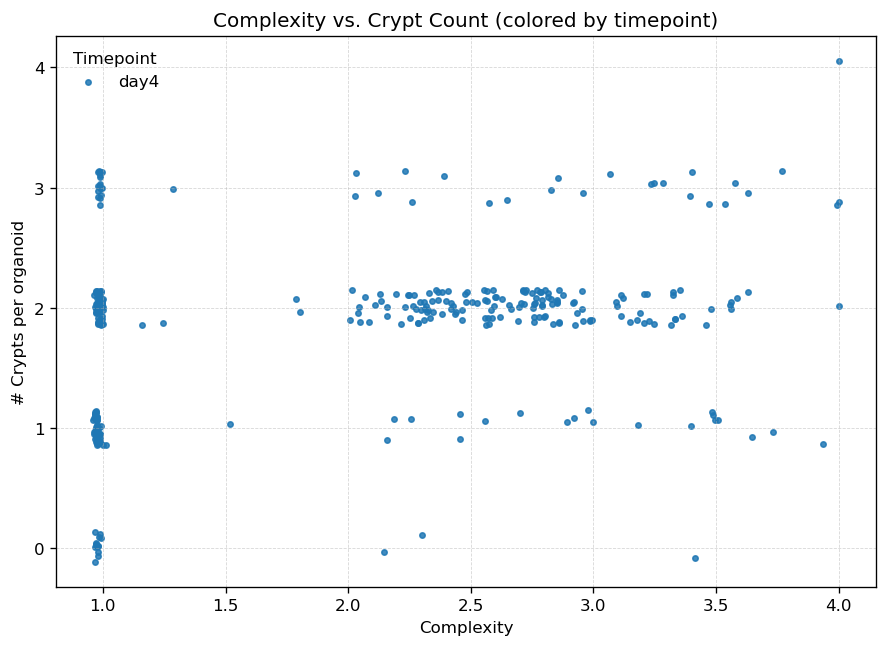

In [4]:
# Collect rows: one per organoid
recs = []
for tp, d in results.items():
    complexities = d.get("complexity", [])
    crypts_all  = d.get("crypts_all", [])
    labels      = d.get("label_uid", [])
    n_items = min(len(complexities), len(crypts_all), len(labels))
    for i in range(n_items):
        cval = complexities[i]
        if cval is None or (isinstance(cval, float) and np.isnan(cval)):
            continue
        crypts_i = crypts_all[i]
        # crypts_i is typically a list (or list-like) of regions; fall back to 0 if None
        n_crypts = len(crypts_i) if crypts_i is not None else 0
        recs.append({
            "timepoint": tp,
            "complexity": float(cval),
            "n_crypts": int(n_crypts),
            "label_uid": labels[i]
        })

df = pd.DataFrame(recs)

# Build a consistent color per timepoint
unique_tps = sorted(df["timepoint"].unique())
cmap = plt.get_cmap("tab10")
color_map = {tp: cmap(i % 10) for i, tp in enumerate(unique_tps)}

plt.figure(figsize=(7.5, 5.5), dpi=120)
for tp in unique_tps:
    sub = df[df["timepoint"] == tp]
    n_crypts_jittered = sub["n_crypts"] + np.random.uniform(-0.15, 0.15, len(sub))

    plt.scatter(
        sub["complexity"],
        n_crypts_jittered,
        label=tp,
        alpha=0.85,
        s=10,
        c=[color_map[tp]]  # keep a single color per timepoint
    )

plt.xlabel("Complexity")
plt.ylabel("# Crypts per organoid")
plt.title("Complexity vs. Crypt Count (colored by timepoint)")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend(title="Timepoint", frameon=False)

plt.tight_layout()
plt.show()

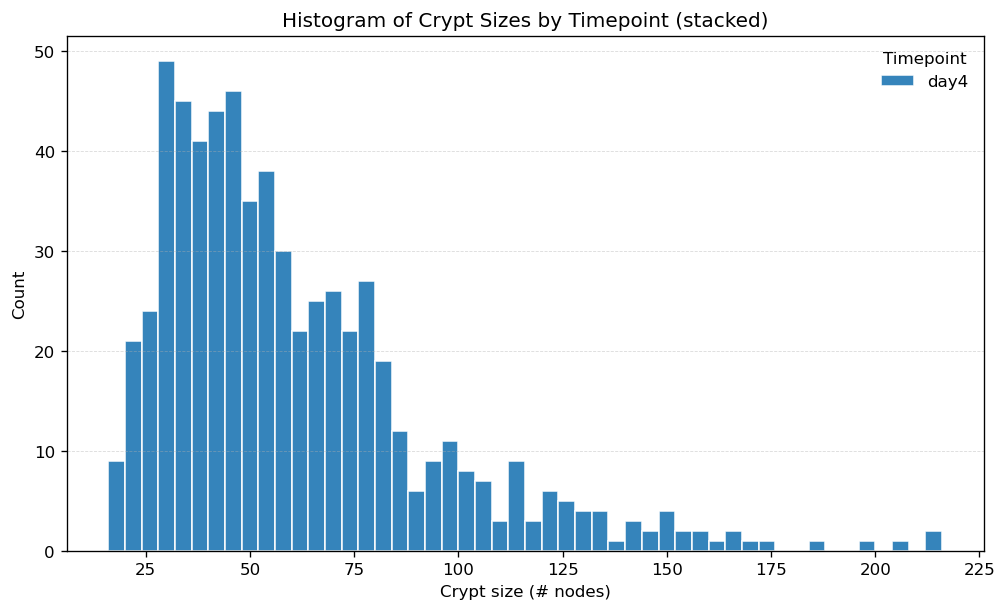

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build DataFrame of crypt sizes (as you already did)
size_recs = []
for tp, d in results.items():
    crypts_all  = d.get("crypts_all", [])
    labels      = d.get("label_uid", [])
    n_items = min(len(crypts_all), len(labels))
    for i in range(n_items):
        crypts_i = crypts_all[i] or []
        for k, patch in enumerate(crypts_i):
            size_recs.append({
                "timepoint": tp,
                "label_uid": labels[i],
                "crypt_idx": k,
                "size": len(patch),
            })

sizes_df = pd.DataFrame(size_recs)
if sizes_df.empty:
    raise RuntimeError("No crypt sizes to plot.")

# Shared bin edges for all timepoints
bins = 50
bin_edges = np.histogram_bin_edges(sizes_df["size"].values, bins=bins)
bin_widths = np.diff(bin_edges)
bin_centers = bin_edges[:-1] + 0.5 * bin_widths

# Count per timepoint per bin
unique_tps = sorted(sizes_df["timepoint"].unique())
counts_per_tp = []
for tp in unique_tps:
    vals = sizes_df.loc[sizes_df["timepoint"] == tp, "size"].values
    counts, _ = np.histogram(vals, bins=bin_edges)
    counts_per_tp.append(counts)

# Plot stacked bars
plt.figure(figsize=(8.5, 5.2), dpi=120)
bottom = np.zeros_like(bin_centers, dtype=float)

cmap = plt.get_cmap("tab10")
for i, tp in enumerate(unique_tps):
    counts = counts_per_tp[i]
    plt.bar(
        bin_centers,
        counts,
        width=bin_widths,
        bottom=bottom,
        label=str(tp),
        edgecolor="white",
        alpha=0.9,
        align="center",
        color=cmap(i % 10),
    )
    bottom += counts

plt.xlabel("Crypt size (# nodes)")
plt.ylabel("Count")
plt.title("Histogram of Crypt Sizes by Timepoint (stacked)")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.45)
plt.legend(title="Timepoint", frameon=False, ncol=2)
plt.tight_layout()
plt.show()


In [6]:
import numpy as np

def plot_random_samples_by_filters(
    results,
    k=3,
    n_crypts=None,                 # e.g. 3 for exact match
    n_crypts_range=None,           # e.g. (2, 5) inclusive; ignored if n_crypts is set
    complexity_range=None,         # e.g. (0.2, 0.6) inclusive
    seed=None,
    node_size=2,
    colorscale='YlOrRd'
):
    """
    Pool across all timepoints, filter by #crypts and complexity, sample k organoids, and plot.

    Parameters
    ----------
    results : dict
        Your per-timepoint results structure.
    k : int
        Number of random samples to plot (pooled across timepoints).
    n_crypts : int or None
        Exact number of crypts to match. If provided, overrides n_crypts_range.
    n_crypts_range : (int, int) or None
        Inclusive range for number of crypts; ignored if n_crypts is not None.
    complexity_range : (float, float) or None
        Inclusive range for complexity. If None, no complexity filtering.
    seed : int or None
        Seed for reproducible sampling. If None, sampling is unseeded.
    node_size : int
        Passed to plot_organoid_graph.
    colorscale : str
        Passed to add_region_overlays for crypts overlay.
    """
    # Gather all candidates as (tp, idx) pairs after filtering
    candidates = []
    for tp, d in results.items():
        comp_arr   = d.get("complexity", [])
        crypts_all = d.get("crypts_all", [])
        N = min(len(comp_arr), len(crypts_all))
        for i in range(N):
            cval = comp_arr[i]
            if cval is None or (isinstance(cval, float) and np.isnan(cval)):
                continue

            n_cr = len(crypts_all[i]) if crypts_all[i] is not None else 0

            # Filter by number of crypts
            if n_crypts is not None:
                if n_cr != int(n_crypts):
                    continue
            elif n_crypts_range is not None:
                lo, hi = n_crypts_range
                if not (lo <= n_cr <= hi):
                    continue

            # Filter by complexity
            if complexity_range is not None:
                clo, chi = complexity_range
                if not (clo <= float(cval) <= chi):
                    continue

            candidates.append((tp, i))

    if not candidates:
        msg = "No organoids match the filters"
        parts = []
        if n_crypts is not None: parts.append(f"#crypts == {n_crypts}")
        elif n_crypts_range is not None: parts.append(f"{n_crypts_range[0]} ≤ #crypts ≤ {n_crypts_range[1]}")
        if complexity_range is not None: parts.append(f"{complexity_range[0]} ≤ complexity ≤ {complexity_range[1]}")
        if parts: msg += f" ({', '.join(parts)})."
        print(msg)
        return

    if seed is not None:
        np.random.seed(seed)

    choose_k = min(k, len(candidates))
    sel_idxs = np.random.choice(len(candidates), size=choose_k, replace=False)

    for j in sel_idxs:
        tp, i = candidates[j]
        d = results[tp]

        G = d['cell_graphs_all'][i]
        proj_points = np.array([G.nodes[n]["proj_point"] for n in G.nodes])
        HKS = np.array([G.nodes[n]["hks"] for n in G.nodes])

        fig = plot_organoid_graph(
            proj_points,
            G,
            HKS[:, 0],
            node_size=node_size
        )
        # crypts overlay
        add_region_overlays(fig, proj_points, d['crypts_all'][i], colorscale=colorscale)
        # villus overlay
        # add_region_overlays(fig, d['centroids_all'][i], [d['villus_all'][i]])

        # Optional: annotate for context
        try:
            cval = float(d['complexity'][i])
            n_cr = len(d['crypts_all'][i]) if d['crypts_all'][i] is not None else 0
            fig.update_layout(title=f"{d['label_uid'][i]} | complexity={cval:.3f}, #crypts={n_cr}")
        except Exception:
            pass

        fig.show()



# ---- Example calls ----
# Exact #crypts = 3, any complexity:
plot_random_samples_by_filters(results, k=3, n_crypts=3, complexity_range=(-1, 1))

# #crypts in [2,5] and complexity in [0.2, 0.6]:
# plot_random_samples_by_filters(results, k=4, n_crypts_range=(2,5), complexity_range=(0.2, 0.6))


# Refine and analyze morphology of crypts

Adjust crypt boundaries and extract profiles along crypt axis

In [7]:
data_dir = '../NicoleData/20250929/fractal_output'

timepoints = ['day2', 'day2p5', 'day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']   # extend as needed: ['day3', 'day3p5', ...]
zarr_names = {tp: 'r0.zarr' for tp in timepoints}
rounds     = {tp: '0_fused_zillum_registered' for tp in timepoints}
meshes     = {tp: 'nnorg_linked_multi_annotated_class' for tp in timepoints}

wells = {
    'day1p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day3': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'B02', 'B03'],
    'day3p5': ['A01', 'A02', 'A03', 'A04', 'B03'],
    'day4': ['A02', 'A03', 'A04', 'A05', 'A06', 'B01', 'B02'],
    'day4p5': ['A06', 'B06'],
    'day4p5-more': ['C01', 'C02', 'C03', 'C04', 'C05', 'C06'],
}

def mesh_path_from_label_uid(label_uid):
    """
    Reconstruct the .vtp mesh path from a label_uid of the form
    '{tp}_{well}_{organoid_id}'.

    This assumes the same directory layout as in preprocess_organoid_graphs.py.
    """
    parts = label_uid.split("_")
    if len(parts) < 3:
        raise ValueError(f"Unexpected label_uid format: {label_uid}")

    tp   = parts[0]
    well = parts[1]
    organoid_id = "_".join(parts[2:])  # in case organoid_id itself has underscores

    plate = well[0]
    field = well[1:]

    zarr_name  = zarr_names[tp]
    round_name = rounds[tp]
    mesh_name  = meshes[tp]

    base_dir = os.path.join(data_dir, tp, zarr_name, plate, field, round_name)
    mesh_dir = os.path.join(base_dir, "meshes", mesh_name)
    mesh_path = os.path.join(mesh_dir, f"{organoid_id}.vtp")

    return mesh_path

In [ ]:
from src.crypt_analysis import *
from src.nuclei_to_mesh_projection import center_and_rescale_mesh, extract_cell_attributes

import os
from tqdm import tqdm

# ============================================================
# Helpers to read graph attributes
# ============================================================

def get_proj_vertex_ids_from_graph(G):
    """(N_cells,) int, from node attribute 'proj_vertex'."""
    n = G.number_of_nodes()
    return np.array([int(G.nodes[i]["proj_vertex"]) for i in range(n)], dtype=np.int64)

def get_markers_from_graph(G):
    """(N_cells, M) markers matrix from node attribute 'markers_bin'."""
    return np.asarray([G.nodes[i]["markers_bin"] for i in range(G.number_of_nodes())])


# ============================================================
# Ensemble crypt analysis loop 
# ============================================================

CELLS_CSV = "../NicoleData/features_csv/features/cell_types_class.csv"   # <-- adjust
cells_df = pd.read_csv(CELLS_CSV)



# ---- analysis configuration (match single-organoid notebook) ----
S = 1.5
n_bins = 80
bin_edges   = np.linspace(0.0, S, n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# raw-distance bins for correlations (keep as before; adjust if needed)
bin_edges_raw = np.linspace(0.0, 10.0, n_bins + 1)

# HKS times on mesh vertices
t_hks_vertices = [1.0, 2.0, 4.0, 8.0, 25.0]
t_corr_idx = 0  # which HKS time-scale to correlate (index into t_hks_vertices)

# storage across timepoints
timepoints = list(results.keys())
n_tp = len(timepoints)

M = None
num_pos_per_bin   = None                 # (n_tp, M, n_bins)
num_cells_per_bin = np.zeros((n_tp, n_bins), dtype=float)

# per-timepoint per-crypt lists (convert to arrays at the end)
crypt_circumferences_all  = [[] for _ in range(n_tp)]  # 
marker_pos_counts_all = [[] for _ in range(n_tp)]   # each entry: (M, n_bins)
marker_cell_counts_all = [[] for _ in range(n_tp)]  # each entry: (n_bins,)

curv_mean_all  = [[] for _ in range(n_tp)]  # mean HKS along s (adjusted)
curv_std_all   = [[] for _ in range(n_tp)]  # std  HKS along s (adjusted)

BI_all = [[] for _ in range(n_tp)]
CI_all = [[] for _ in range(n_tp)]
EI_all = [[] for _ in range(n_tp)]


for tp_idx, tp in enumerate(timepoints):  # loop over timepoints
    d = results[tp]

    crypts_all   = d.get("crypts_all", [])
    villus_all   = d.get("villus_all", [])
    necks_all    = d.get("necks_all", [])     # <-- NEW (all extracted necks)
    Gs           = d.get("cell_graphs_all", [])
    label_uids   = d.get("label_uid", [])

    if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()
    if isinstance(villus_all, np.ndarray): villus_all = villus_all.tolist()
    if isinstance(necks_all, np.ndarray):  necks_all  = necks_all.tolist()

    for i in tqdm(range(len(Gs)), desc=f"{tp}"):  # loop over organoids in timepoint
        G = Gs[i]

        crypt_patches  = as_patch_list(crypts_all[i] if i < len(crypts_all) else None)
        villus_patches = as_patch_list(villus_all[i] if i < len(villus_all) else None)
        neck_patches   = as_patch_list(necks_all[i]  if i < len(necks_all)  else None)

        if not crypt_patches:
            continue

        # --- per-cell markers ---
        markers_bin = get_markers_from_graph(G)  # (N_cells, M)
        if M is None:
            M = markers_bin.shape[1]
            num_pos_per_bin = np.zeros((n_tp, M, n_bins), dtype=float)

        # --- load mesh for this organoid ---
        label_uid = label_uids[i]
        mesh_path = mesh_path_from_label_uid(label_uid)
        if not os.path.exists(mesh_path):
            print(f"[{tp}] missing mesh: {mesh_path}")
            continue

        mesh = OrganoidMesh(mesh_path)


        # load nuclei data to rescale
        nuclei_df_org = cells_df[cells_df["label_uid"] == label_uid].copy()
        nuclei_xyz, markers_bin = extract_cell_attributes(nuclei_df_org)
        v_new, nuclei_xyz = center_and_rescale_mesh(mesh, nuclei_xyz)
        mesh.v = v_new

        # mesh._eig_decomp()

        # --- proj vertex ids (cell centers) from graph ---
        proj_vertex_ids = get_proj_vertex_ids_from_graph(G)  # (N_cells,)

        # --- compute vertex-level HKS on this mesh ---
        # HKS = compute_hks(mesh, t=t_hks_vertices, coeffs=False)  # (V, T)
        # X = HKS[:, t_corr_idx]  # (V,)

        # weights for correlations + field stats
        # w_v = vertex_areas(mesh)

        # combine villus + neck into boundary patches (matches single-organoid code)
        boundary_patches = []
        if villus_patches:
            boundary_patches.extend(villus_patches)
        if neck_patches:
            boundary_patches.extend(neck_patches)

        # ============================================================
        # Process each crypt (UPDATED)
        # ============================================================

        K = len(crypt_patches)
        bottom_cell_ids = np.full(K, -1, dtype=int)
        bottom_vertex_ids = np.full(K, -1, dtype=int)
        neck_boundary_cells_list = [None] * K

        # 1) precompute boundary + bottom per crypt
        for j, crypt_cells in enumerate(crypt_patches):
            crypt_cells = set(crypt_cells)
            if len(crypt_cells) == 0:
                continue

            neck_boundary_cells = crypt_neck_boundary_cells(G, crypt_cells, boundary_patches)
            if len(neck_boundary_cells) == 0:
                continue

            bottom_cell_id, _ = find_crypt_bottom_lightweight(
                G=G, mesh=mesh, crypt_cells=crypt_cells,
                neck_boundary_cells=neck_boundary_cells,
                candidates="all", score="cv"
            )

            bottom_cell_ids[j] = int(bottom_cell_id)
            bottom_vertex_ids[j] = int(G.nodes[int(bottom_cell_id)]["proj_vertex"])
            neck_boundary_cells_list[j] = list(neck_boundary_cells)


        valid = bottom_vertex_ids >= 0
        sources = bottom_vertex_ids[valid].tolist()

        # Multi-source geodesics: should return distances from each source to all vertices
        # You need to adapt this line to your compute_geodesics signature/return format

        # D_vertices_multi = compute_geodesics(mesh, sources=sources, t=None)  # shape (len(sources), V) ideally
        D_vertices_multi = compute_geodesics_dijkstra(mesh, sources=sources, t=None)  # shape (len(sources), V) ideally


        # index mapping from crypt j -> row in D_vertices_multi
        src_idx_map = {crypt_j: k for k, crypt_j in enumerate(np.where(valid)[0])}

        # We'll build a filtered crypt list + a distance matrix only for kept crypts
        kept_crypt_patches = []
        kept_rows = []  # maps kept_row -> original crypt index j (optional, for debugging)
        dnorm_cellcenters_crypts = np.full((len(crypt_patches), G.number_of_nodes()), np.nan, dtype=float)

        kept_row = 0

        for j, crypt_cells in enumerate(crypt_patches):
            crypt_cells = set(crypt_cells)
            if bottom_vertex_ids[j] < 0 or len(crypt_cells) == 0:
                continue

            k = src_idx_map[j]
            dist_vertices = D_vertices_multi[k, :]  # (V,)

            # --- boundary mean distance ---
            neck_boundary_cells = neck_boundary_cells_list[j]
            boundary_vertex_ids = np.array([int(G.nodes[c]["proj_vertex"]) for c in neck_boundary_cells], dtype=int)

            L_mean = float(np.mean(dist_vertices[boundary_vertex_ids]))
            dnorm_vertices = dist_vertices / max(L_mean, 1e-12)

            # cellcenter distances at projected vertices
            dnorm_cellcenters = dnorm_vertices[proj_vertex_ids]

            # 3) circumference vs distance (pre-adjust)
            CC0 = crypt_circumference(mesh=mesh, crypt_dist=dnorm_vertices, levels=bin_centers)

            # 3b) adjust crypt length -> s_star
            s_star = adjust_cryptlength_by_circumference(
                s=bin_centers,
                C=CC0,
                search_interval=(0.75, 1.25),
                window_length=9,
                polyorder=3,
                min_prominence=0.05,
            )
            if not (np.isfinite(s_star) and s_star > 0):
                s_star = 1.0

            L_crypt = float(L_mean) * float(s_star)

            # adjusted distance fields (neck should be at ~1)
            dnorm_vertices_adj = dnorm_vertices / float(s_star)
            dnorm_cellcenters_adj = dnorm_cellcenters / float(s_star)

            # ---------------------------------------------------------
            # REJECT CRYPTS HERE: marker-based post-filter
            # ---------------------------------------------------------
            keep = filter_crypt_by_markers(
                G=G,
                crypt_cells=crypt_cells,
                pos_markers=None,       
                neg_markers=[4], # AldoB       
                pos_min_cells=1,     
                neg_min_cells=2,     
                roi_frac=0.3,          
                dist_bottom=dnorm_cellcenters_adj,
                require_all_pos=False,   
            )

            if not keep:
                # Do NOT append/store anything for this crypt.
                # Since villus is recomputed as all non-crypt later, these cells become villus automatically.
                continue

            # ---------------------------------------------------------
            # If kept: store/append everything using adjusted distances
            # ---------------------------------------------------------
            kept_crypt_patches.append(crypt_cells)
            kept_rows.append(j)

            # circumference vs distance (ADJ)
            CC = crypt_circumference(mesh=mesh, crypt_dist=dnorm_vertices_adj, levels=bin_centers)

            crypt_circumferences_all[tp_idx].append(CC)

            # store adjusted distance profile for neckline reassignment
            dnorm_cellcenters_crypts[kept_row] = dnorm_cellcenters_adj
            kept_row += 1

            # marker positivity vs distance (use adjusted distances!)
            counts_pos, counts_tot = bin_marker_positivity(
                markers=markers_bin,
                distance=dnorm_cellcenters_adj,
                bin_edges=bin_edges,
            )
            marker_pos_counts_all[tp_idx].append(counts_pos.astype(np.float32))   # (M, n_bins)
            marker_cell_counts_all[tp_idx].append(counts_tot.astype(np.float32))  # (n_bins,)

            # # curvature stats along s
            # mu_s, sd_s, _ = field_stats_along_crypt(
            #     HKS[:, 0],
            #     dnorm_vertices_adj,
            #     bin_edges,
            #     weights=w_v,
            # )
            # curv_mean_all[tp_idx].append(mu_s)
            # curv_std_all[tp_idx].append(sd_s)

            # # morphometrics
            # BI, CI, EI = compute_crypt_metrics(
            #     s=bin_centers,
            #     C=CC,
            #     L=L_crypt, # MAYBE NOT NEEDED
            #     mu_hks=mu_s,
            #     std_hks=sd_s,
            # )
            BI = compute_BI(
                s=bin_centers,
                C=CC
            )
            BI_all[tp_idx].append(BI)
            # CI_all[tp_idx].append(CI)
            # EI_all[tp_idx].append(EI)

        # IMPORTANT: dnorm_cellcenters_crypts has shape (K, N_cells) but only first kept_row rows are valid.
        dnorm_cellcenters_crypts = dnorm_cellcenters_crypts[:kept_row, :]

        # Readjust crypt boundary to neckline
        if kept_row == 0:
            crypt_patches_adj = []  # everything becomes villus
        else:
            crypt_patches_adj, _, _ = assign_crypts_by_neckline(dnorm_cellcenters_crypts)

        # ------------------------------
        # UPDATE results[tp]["crypts_all"][i] IN-PLACE
        # ------------------------------
        # Ensure storage exists and is long enough
        if "crypts_all" not in results[tp]:
            results[tp]["crypts_all"] = []
        while len(results[tp]["crypts_all"]) <= i:
            results[tp]["crypts_all"].append([])

        # Convert to list-of-lists (JSON/pickle friendly), drop empties
        results[tp]["crypts_all"][i] = [
            sorted(list(p)) for p in crypt_patches_adj if (p is not None and len(p) > 0)
        ]


        # ============================================================
        # Readjust VILLUS: all cells that are NOT crypt become villus
        # ============================================================

        # Ensure storage exists and is long enough
        if "villus_all" not in results[tp]:
            results[tp]["villus_all"] = []
        while len(results[tp]["villus_all"]) <= i:
            results[tp]["villus_all"].append([])

        # union of all crypt cells after adjustment
        crypt_union = set()
        for p in results[tp]["crypts_all"][i]:
            crypt_union.update(p)

        # villus = all cells not in crypts
        all_cells = set(range(G.number_of_nodes()))
        villus_cells_adj = sorted(list(all_cells - crypt_union))

        # store as a single villus patch
        results[tp]["villus_all"][i] = [villus_cells_adj]




day4: 100%|██████████| 358/358 [06:10<00:00,  1.04s/it]


In [9]:
# ============================================================
# Convert per-crypt lists into arrays for convenience
# ============================================================

def _list_to_array(list_of_vecs, n_bins):
    return np.asarray(list_of_vecs) if len(list_of_vecs) else np.empty((0, n_bins), dtype=float)

crypt_circumferences_all     = [_list_to_array(x, n_bins) for x in crypt_circumferences_all]

curv_mean_all = [_list_to_array(x, n_bins) for x in curv_mean_all]
curv_std_all  = [_list_to_array(x, n_bins) for x in curv_std_all]

marker_pos_counts_all  = [_list_to_array(x, n_bins) for x in marker_pos_counts_all]
marker_cell_counts_all  = [_list_to_array(x, n_bins) for x in marker_cell_counts_all]

BI_all = [np.asarray(x, dtype=float) if len(x) else np.empty((0,), dtype=float) for x in BI_all]
CI_all = [np.asarray(x, dtype=float) if len(x) else np.empty((0,), dtype=float) for x in CI_all]
EI_all = [np.asarray(x, dtype=float) if len(x) else np.empty((0,), dtype=float) for x in EI_all]


# Analyse marker content of crypts

In [10]:
def get_marker_counts_per_patch(patch, markers):
    idx = np.fromiter(patch, dtype=np.int64)
    num_pos_cells = np.sum(markers[idx, :], axis=0).astype(np.int64)
    num_cells = len(idx)
    return num_pos_cells, num_cells

def split_villus_by_organoid(villus_patches, crypt_patches):
    """Return (villus_only, villus_with_crypts) as two lists of sets."""
    if crypt_patches and len(crypt_patches) > 0:
        return [], list(villus_patches)
    else:
        return list(villus_patches), []

def assign_coexpression_category(patch, bin_markers, i_LGR5, i_Sero, i_Lyso, pos_threshold=1):
    idx = np.fromiter(patch, dtype=np.int64)
    bin_markers_patch = bin_markers[idx, :]

    has_marker = np.sum(bin_markers_patch, axis=0) >= pos_threshold

    # Write out full co-expression conditions (same style as marker_coexpression)
    c0 = has_marker[i_LGR5] and has_marker[i_Sero] and (not has_marker[i_Lyso])
    c1 = has_marker[i_LGR5] and has_marker[i_Lyso] and (not has_marker[i_Sero])
    c2 = has_marker[i_LGR5] and (not has_marker[i_Lyso]) and (not has_marker[i_Sero])
    c3 = has_marker[i_LGR5] and (has_marker[i_Lyso] and has_marker[i_Sero])
    c4 = (not has_marker[i_LGR5])

    # Convert the one-hot-ish conditions to a single index.
    # These should be mutually exclusive and cover all cases.
    conds = np.array([c0, c1, c2, c3, c4], dtype=np.int64)

    hits = np.flatnonzero(conds)
    if hits.size == 1:
        return int(hits[0])
    else:
        return np.nan


# ----------------------------
# Config
# ----------------------------
min_positive  = 1
pos_threshold = 1

i_LGR5 = marker_names.index("LGR5")
i_Sero = marker_names.index("Serotonin")
i_Lyso = marker_names.index("Lysozyme")

labels_cond_5 = [
    "LGR5 & Sero & NO Lyso",
    "LGR5 & Lyso & NO Sero",
    "LGR5 & NO (Sero | Lyso)",
    "LGR5 & (Sero & Lyso)",
    "NO LGR5",
]

# patch_type codes (NOT BI-dependent)
PT_CRYPT       = 0
PT_VILLUS_ONLY = 1
PT_VILLUS_WITH = 2
patch_type_names = ["Crypt", "Villus-only", "Villus-with-crypts"]


# ============================================================
# Build patch-level dataset once
# ============================================================

patch_tp_idx   = []   # timepoint index for each patch
patch_type     = []   # PT_*
patch_BI       = []   # BI for crypts, np.nan for villus patches
patch_numcells = []   # number of cells in patch
patch_poscells = []   # (M,) number of positive cells per marker in patch
patch_hasmark  = []   # (M,) 0/1 if marker present in patch (>=min_positive pos cells)
patch_cat5     = []   # int in {0..4}

for tp_idx, tp in enumerate(timepoints):
    d = results[tp]
    graphs_all = d.get("cell_graphs_all", [])
    crypts_all = d.get("crypts_all", [])
    villus_all = d.get("villus_all", [])

    if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()
    if isinstance(villus_all, np.ndarray): villus_all = villus_all.tolist()

    BI_tp = np.asarray(BI_all[tp_idx], float)
    bi_ptr = 0  # must match BI_all append order

    for org_idx in range(len(graphs_all)):
        G = graphs_all[org_idx]
        markers = np.asarray([G.nodes[n]["markers_bin"] for n in G.nodes], dtype=np.int64)
        if markers is None:
            continue

        crypt_patches  = _to_patch_list(crypts_all[org_idx] if org_idx < len(crypts_all) else None)
        villus_patches = _to_patch_list(villus_all[org_idx] if org_idx < len(villus_all) else None)

        villus_only, villus_with = split_villus_by_organoid(villus_patches, crypt_patches)

        # --- crypt patches ---
        for patch in crypt_patches:
            patch = set(patch)
            if len(patch) == 0:
                continue

            if bi_ptr >= BI_tp.size:
                raise RuntimeError(
                    f"BI_tp exhausted at tp={tp} (tp_idx={tp_idx}). "
                    "Patch traversal mismatch vs BI_all construction."
                )
            BI = float(BI_tp[bi_ptr])
            bi_ptr += 1

            num_pos_cells, num_cells = get_marker_counts_per_patch(patch, markers)
            has_marker = (num_pos_cells >= min_positive).astype(np.int64)
            cat = assign_coexpression_category(patch, markers, i_LGR5, i_Sero, i_Lyso, pos_threshold=pos_threshold)

            patch_tp_idx.append(tp_idx)
            patch_type.append(PT_CRYPT)
            patch_BI.append(BI)
            patch_numcells.append(int(num_cells))
            patch_poscells.append(num_pos_cells.astype(np.int64))
            patch_hasmark.append(has_marker)
            patch_cat5.append(int(cat))

        # --- villus-only patches ---
        for patch in villus_only:
            patch = set(patch)
            if len(patch) == 0:
                continue

            num_pos_cells, num_cells = get_marker_counts_per_patch(patch, markers)
            has_marker = (num_pos_cells >= min_positive).astype(np.int64)
            cat = assign_coexpression_category(patch, markers, i_LGR5, i_Sero, i_Lyso, pos_threshold=pos_threshold)

            patch_tp_idx.append(tp_idx)
            patch_type.append(PT_VILLUS_ONLY)
            patch_BI.append(np.nan)
            patch_numcells.append(int(num_cells))
            patch_poscells.append(num_pos_cells.astype(np.int64))
            patch_hasmark.append(has_marker)
            patch_cat5.append(int(cat))

        # --- villus-with-crypts patches ---
        for patch in villus_with:
            patch = set(patch)
            if len(patch) == 0:
                continue

            num_pos_cells, num_cells = get_marker_counts_per_patch(patch, markers)
            has_marker = (num_pos_cells >= min_positive).astype(np.int64)
            cat = assign_coexpression_category(patch, markers, i_LGR5, i_Sero, i_Lyso, pos_threshold=pos_threshold)

            patch_tp_idx.append(tp_idx)
            patch_type.append(PT_VILLUS_WITH)
            patch_BI.append(np.nan)
            patch_numcells.append(int(num_cells))
            patch_poscells.append(num_pos_cells.astype(np.int64))
            patch_hasmark.append(has_marker)
            patch_cat5.append(int(cat))

    # Optional sanity for BI alignment
    if bi_ptr != BI_tp.size:
        print(f"[WARN] tp={tp}: consumed {bi_ptr} BI values but BI_all[{tp_idx}] has {BI_tp.size} entries.")

# Convert to arrays
patch_tp_idx   = np.asarray(patch_tp_idx, dtype=int)
patch_type     = np.asarray(patch_type, dtype=int)
patch_BI       = np.asarray(patch_BI, dtype=float)
patch_numcells = np.asarray(patch_numcells, dtype=int)
patch_poscells = np.asarray(patch_poscells, dtype=int)   # (Npatch, M)
patch_hasmark  = np.asarray(patch_hasmark, dtype=int)    # (Npatch, M)
patch_cat5     = np.asarray(patch_cat5, dtype=int)

print("Built patch table with N =", patch_tp_idx.size)


Built patch table with N = 830


#### Set up functions for aggregating features (crypt) across timepoints and categories

In [11]:

# ============================================================
#  Aggregation functions
# ============================================================

def make_selector(
    patch_type_eq=None,     # PT_* or list of PT_*
    tp_idx_eq=None,         # int or list of int
    BI_range=None,          # (lo, hi) inclusive/exclusive: lo <= BI < hi (crypts only)
    BI_eq=None,             # exact BI value (e.g. 0.0)
):
    """
    Returns a boolean mask over patches.
    Notes:
      - BI filters apply only to crypt patches automatically.
      - For villus patches BI is NaN, so they won't pass BI filters.
    """
    m = np.ones(patch_tp_idx.shape[0], dtype=bool)

    if patch_type_eq is not None:
        if np.isscalar(patch_type_eq):
            m &= (patch_type == int(patch_type_eq))
        else:
            m &= np.isin(patch_type, np.asarray(patch_type_eq, dtype=int))

    if tp_idx_eq is not None:
        if np.isscalar(tp_idx_eq):
            m &= (patch_tp_idx == int(tp_idx_eq))
        else:
            m &= np.isin(patch_tp_idx, np.asarray(tp_idx_eq, dtype=int))

    if BI_eq is not None:
        m &= (patch_type == PT_CRYPT) & (patch_BI == float(BI_eq))

    if BI_range is not None:
        lo, hi = BI_range
        lo = -np.inf if lo is None else float(lo)
        hi = +np.inf if hi is None else float(hi)
        m &= (patch_type == PT_CRYPT) & (patch_BI >= lo) & (patch_BI < hi)

    return m

def aggregate_composition(mask):
    """
    Given mask over patches, return three things:
      - frac_marker_presence: (M,) fraction of patches with marker present
      - frac_cell_positive:   (M,) fraction of cells positive (pooled across patches)
      - frac_categories:      (5,) fraction of patches in each coexpression category
    """
    idx = np.where(mask)[0]
    if idx.size == 0:
        M = patch_poscells.shape[1]
        return (np.full(M, np.nan), np.full(M, np.nan), np.full(5, np.nan), 0)

    # Patch-level marker presence
    has_sum = patch_hasmark[idx].sum(axis=0)  # (M,)
    frac_marker_presence = has_sum / float(idx.size)

    # Cell-level positivity
    pos_sum = patch_poscells[idx].sum(axis=0).astype(float)  # (M,)
    cell_sum = float(patch_numcells[idx].sum())
    frac_cell_positive = pos_sum / max(cell_sum, 1.0)

    # Category fractions
    cats = patch_cat5[idx]
    cat_counts = np.bincount(cats, minlength=5).astype(float)
    frac_categories = cat_counts / float(idx.size)

    return frac_marker_presence, frac_cell_positive, frac_categories, int(idx.size)


#### Plot marker content of features 

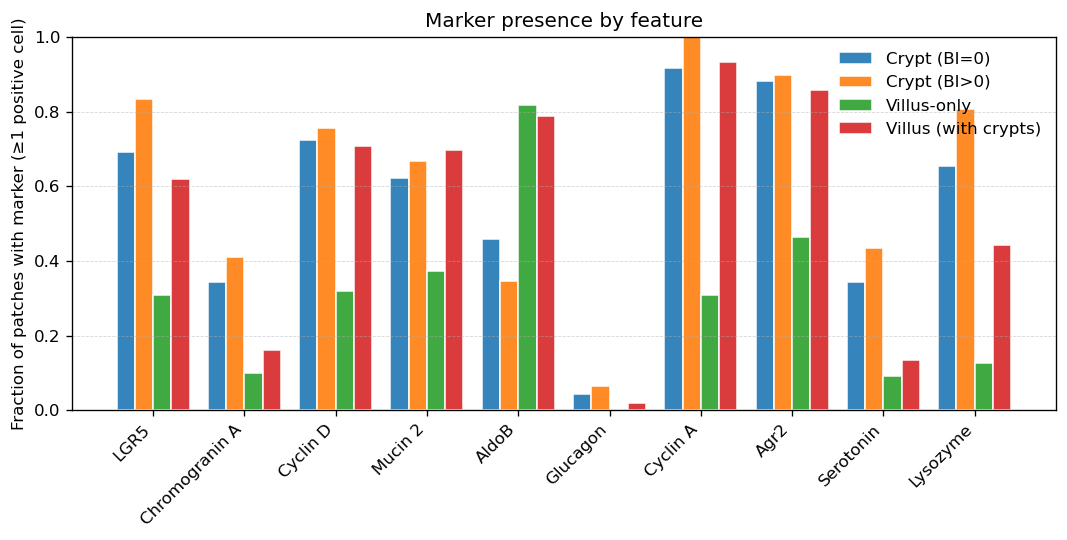

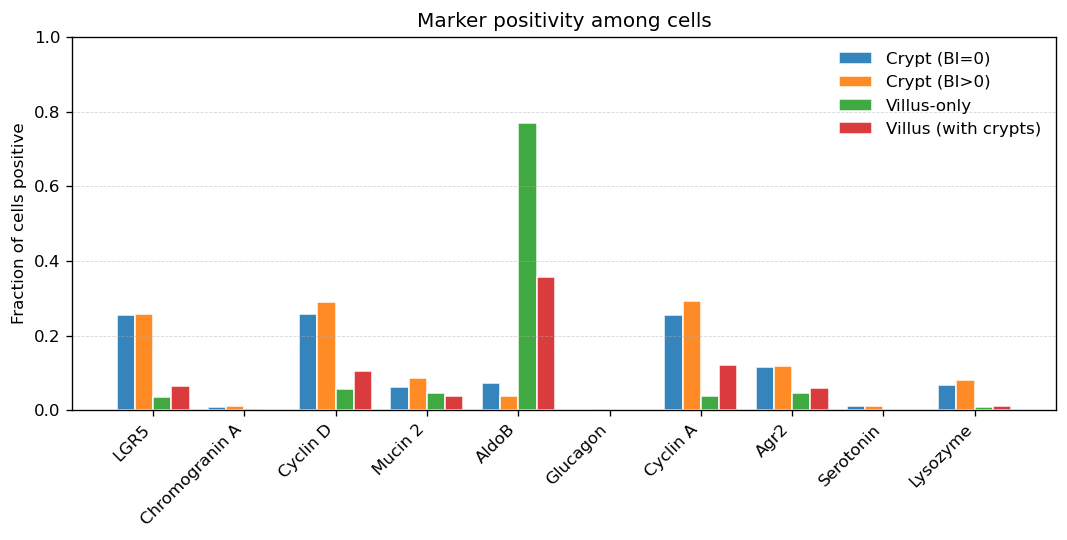

N patches per plotted group: {'Crypt (BI=0)': 368, 'Crypt (BI>0)': 78, 'Villus-only': 110, 'Villus (with crypts)': 274}


In [12]:
def _plot_grouped_bars(vals, xtick_labels, ylabel, title, group_names):
    """
    vals: (n_groups, K)
    """
    vals = np.asarray(vals, float)
    n_groups, K = vals.shape
    x = np.arange(K)
    w = min(0.22, 0.8 / max(n_groups, 1))

    plt.figure(figsize=(max(9, 0.5*K), 4.6), dpi=120)
    offsets = (np.arange(n_groups) - (n_groups - 1) / 2) * w

    for gi in range(n_groups):
        plt.bar(x + offsets[gi], vals[gi], width=w, label=group_names[gi],
                edgecolor="white", alpha=0.9)

    plt.xticks(x, xtick_labels, rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()




# Choose which groups you want in the plot by defining selectors.
plot_groups = [
    ("Crypt (BI=0)",            make_selector(patch_type_eq=PT_CRYPT, BI_eq=0.0)),
    ("Crypt (BI>0)",            make_selector(patch_type_eq=PT_CRYPT, BI_range=(1e-12, None))),
    ("Villus-only",             make_selector(patch_type_eq=PT_VILLUS_ONLY)),
    ("Villus (with crypts)",    make_selector(patch_type_eq=PT_VILLUS_WITH)),
    # Example extra group:
    # ("0<BI<0.5",               make_selector(patch_type_eq=PT_CRYPT, BI_range=(1e-12, 0.5))),
]

group_names = [g[0] for g in plot_groups]
masks = [g[1] for g in plot_groups]

# Build (n_groups, M) arrays by aggregating each mask
frac_marker_presence = []
frac_cell_positive = []
frac_categories = []
Ns = []

for m in masks:
    fp, fc, fcat, n = aggregate_composition(m)
    frac_marker_presence.append(fp)   # (M,)
    frac_cell_positive.append(fc)     # (M,)
    frac_categories.append(fcat)      # (5,)
    Ns.append(n)

frac_marker_presence = np.vstack(frac_marker_presence)  # (n_groups, M)
frac_cell_positive   = np.vstack(frac_cell_positive)    # (n_groups, M)
frac_categories      = np.vstack(frac_categories)       # (n_groups, 5)

# --- Plot 1: patch-level marker presence (your old Figure 1) ---
_plot_grouped_bars(
    frac_marker_presence,
    marker_names,
    ylabel=f"Fraction of patches with marker (≥{min_positive} positive cell)",
    title="Marker presence by feature",
    group_names=group_names,
)

# --- Plot 2: cell-level positivity (your old Figure 2 equivalent) ---
_plot_grouped_bars(
    frac_cell_positive,
    marker_names,
    ylabel="Fraction of cells positive",
    title="Marker positivity among cells",
    group_names=group_names,
)

print("N patches per plotted group:", dict(zip(group_names, Ns)))


In [13]:
# import pandas as pd

# # ============================================================
# # Marker indices (from your existing scope)
# # ============================================================
# i_LGR5 = marker_names.index("LGR5")
# i_Sero = marker_names.index("Serotonin")
# i_Lyso = marker_names.index("Lysozyme")

# # Category labels (must match your refactor)
# labels_cond_5 = [
#     "LGR5 & Sero & NO Lyso",
#     "LGR5 & Lyso & NO Sero",
#     "LGR5 & NO (Sero | Lyso)",
#     "LGR5 & (Sero & Lyso)",
#     "NO LGR5",
# ]

# # ============================================================
# # Expected fractions under independence
# # ============================================================
# def expected_coexpression_fractions_from_marker_presence(p_L, p_S, p_Y):
#     """
#     Returns expected fractions for the 5 co-expression categories
#     assuming marker independence at the patch level.
#     """
#     exp = np.zeros(5, dtype=float)

#     exp[0] = p_L * p_S * (1.0 - p_Y)           # LGR5 & Sero & NO Lyso
#     exp[1] = p_L * p_Y * (1.0 - p_S)           # LGR5 & Lyso & NO Sero
#     exp[2] = p_L * (1.0 - p_S) * (1.0 - p_Y)   # LGR5 & NO (Sero | Lyso)
#     exp[3] = p_L * p_S * p_Y                   # LGR5 & (Sero & Lyso)
#     exp[4] = 1.0 - p_L                         # NO LGR5

#     return exp


# # ============================================================
# # Main analysis across feature groups
# # ============================================================
# def expected_coexpression_by_group(plot_groups, aggregate_composition):
#     """
#     For each feature group, compute the expected co-expression
#     fractions under marker independence.

#     Returns:
#         dict[group_name] -> dict with:
#             - p_markers: dict of marginal marker probabilities
#             - expected_frac: (5,) expected fractions
#             - observed_frac: (5,) observed fractions
#             - n_patches: int
#     """
#     results = {}

#     for gname, selector in plot_groups:
#         frac_marker_presence, _, frac_categories_obs, n = aggregate_composition(selector)

#         # marginal probabilities (patch-level)
#         p_L = frac_marker_presence[i_LGR5]
#         p_S = frac_marker_presence[i_Sero]
#         p_Y = frac_marker_presence[i_Lyso]

#         expected_frac = expected_coexpression_fractions_from_marker_presence(
#             p_L, p_S, p_Y
#         )

#         results[gname] = dict(
#             p_markers=dict(LGR5=p_L, Serotonin=p_S, Lysozyme=p_Y),
#             expected_frac=expected_frac,
#             observed_frac=frac_categories_obs,
#             n_patches=n,
#         )

#     return results


# # ============================================================
# # Example usage (crypts + villi)
# # ============================================================
# plot_groups = [
#     ("Crypt (BI=0)",     make_selector(patch_type_eq=PT_CRYPT, BI_eq=0.0)),
#     ("Crypt (BI>0)",     make_selector(patch_type_eq=PT_CRYPT, BI_range=(1e-12, None))),
#     ("Villus-only",      make_selector(patch_type_eq=PT_VILLUS_ONLY)),
#     ("Villus (with crypts)", make_selector(patch_type_eq=PT_VILLUS_WITH)),
# ]

# expected_results = expected_coexpression_by_group(
#     plot_groups,
#     aggregate_composition
# )

# # ============================================================
# # Nicely formatted table output
# # ============================================================
# tables = {}
# for gname, res in expected_results.items():
#     df = pd.DataFrame({
#         "Observed fraction": res["observed_frac"],
#         "Expected (independent)": res["expected_frac"],
#         "Observed / Expected": np.divide(
#             res["observed_frac"],
#             res["expected_frac"],
#             out=np.full(5, np.nan),
#             where=res["expected_frac"] > 0
#         ),
#     }, index=labels_cond_5)

#     tables[gname] = df

#     print(f"\n=== {gname} ===")
#     print(f"N patches = {res['n_patches']}")
#     print("Marker presence:")
#     for k, v in res["p_markers"].items():
#         print(f"  {k:>10s}: {v:.3f}")
#     display(df)


#### Calculate and plot expected vs observed occurrence of co-expression categories

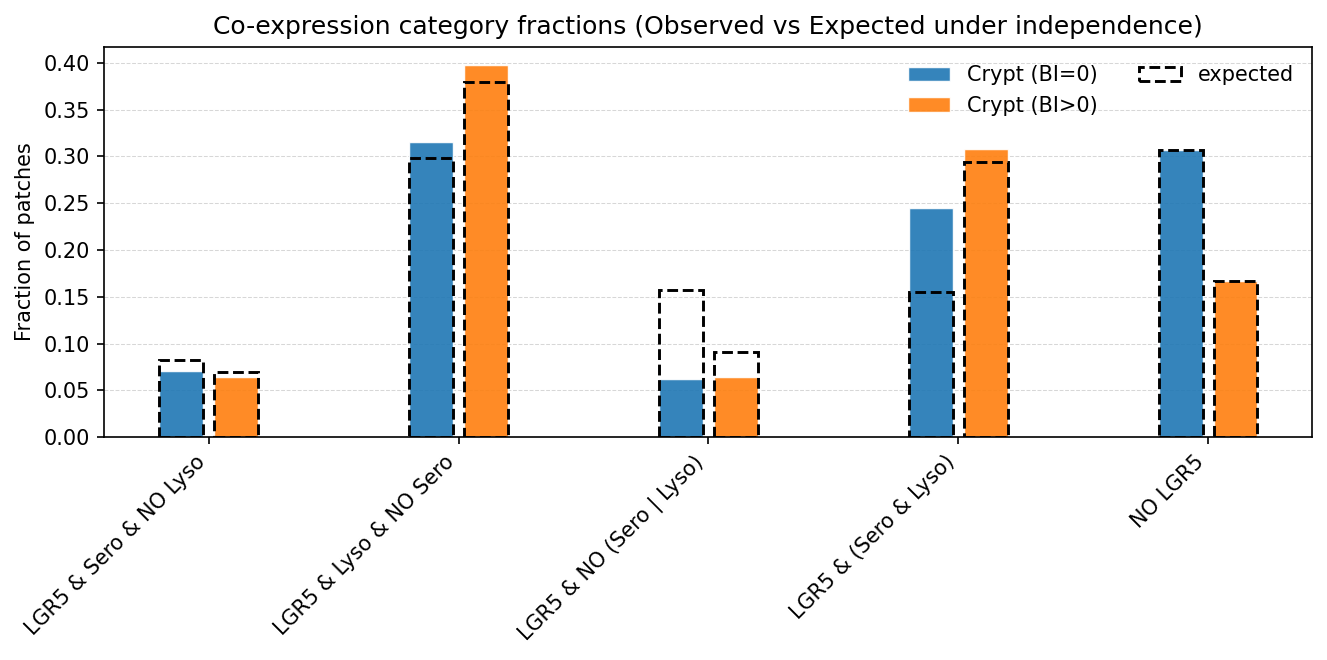

N patches per plotted group: {'Crypt (BI=0)': 368, 'Crypt (BI>0)': 78}


In [14]:
# ------------------------------------------------------------
# Indpendence-model expected fractions from patch-level marker presence
# (must match your 5-category definition / labels_cond_5 ordering)
# ------------------------------------------------------------
i_LGR5 = marker_names.index("LGR5")
i_Sero = marker_names.index("Serotonin")
i_Lyso = marker_names.index("Lysozyme")

def expected_coexpression_fractions_from_marker_presence(fp_marker, i_LGR5, i_Sero, i_Lyso):
    """
    fp_marker: (M,) patch-level marker presence fractions for a given group.
    Returns: (5,) expected fractions under independence, in labels_cond_5 order.
    """
    pL = float(fp_marker[i_LGR5])
    pS = float(fp_marker[i_Sero])
    pY = float(fp_marker[i_Lyso])

    exp = np.zeros(5, dtype=float)
    exp[0] = pL * pS * (1.0 - pY)           # LGR5 & Sero & NO Lyso
    exp[1] = pL * pY * (1.0 - pS)           # LGR5 & Lyso & NO Sero
    exp[2] = pL * (1.0 - pS) * (1.0 - pY)   # LGR5 & NO (Sero | Lyso)
    exp[3] = pL * pS * pY                   # LGR5 & (Sero & Lyso)
    exp[4] = 1.0 - pL                       # NO LGR5
    return exp

# ------------------------------------------------------------
# Updated plotting: grouped bars (Observed) + markers (Expected)
# ------------------------------------------------------------
def plot_grouped_bars_with_expected(observed, expected, xtick_labels, ylabel, title, group_names):
    """
    observed: (n_groups, K)
    expected: (n_groups, K)
    """
    observed = np.asarray(observed, float)
    expected = np.asarray(expected, float)
    assert observed.shape == expected.shape

    n_groups, K = observed.shape
    x = np.arange(K)
    w = min(0.22, 0.8 / max(n_groups, 1))
    offsets = (np.arange(n_groups) - (n_groups - 1) / 2) * w

    fig, ax = plt.subplots(figsize=(max(9, 0.5*K), 4.5), dpi=150)

    # --- observed: filled bars ---
    for gi in range(n_groups):
        ax.bar(
            x + offsets[gi],
            observed[gi],
            width=0.8*w,
            label=f"{group_names[gi]}",
            edgecolor="white",
            linewidth=0.7,
            alpha=0.9,
            zorder=2,
        )

    # --- expected: hollow dashed-outline bars ---
    for gi in range(n_groups):
        ax.bar(
            x + offsets[gi],
            expected[gi],
            width=0.8*w,
            facecolor="none",
            edgecolor="black",
            linewidth=1.4,
            linestyle="--",
            label=f"expected" if gi == 0 else None,
            zorder=3,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(xtick_labels, rotation=45, ha="right")
    # ax.set_ylim(0, 1)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.legend(frameon=False, ncol=2)
    fig.tight_layout()
    plt.show()

# ============================================================
# Choose groups + aggregate 
# ============================================================
plot_groups = [
    ("Crypt (BI=0)",            make_selector(patch_type_eq=PT_CRYPT, BI_eq=0.0)),
    ("Crypt (BI>0)",            make_selector(patch_type_eq=PT_CRYPT, BI_range=(1e-12, None))),
    # ("Villus-only",             make_selector(patch_type_eq=PT_VILLUS_ONLY)),
    # ("Villus (with crypts)",    make_selector(patch_type_eq=PT_VILLUS_WITH)),
]

group_names = [g[0] for g in plot_groups]
masks = [g[1] for g in plot_groups]

frac_marker_presence = []
frac_cell_positive = []
frac_categories_obs = []
Ns = []

for m in masks:
    fp, fc, fcat, n = aggregate_composition(m)
    frac_marker_presence.append(fp)   # (M,)
    frac_cell_positive.append(fc)     # (M,)
    frac_categories_obs.append(fcat)  # (5,)
    Ns.append(n)

frac_marker_presence = np.vstack(frac_marker_presence)      # (G, M)
frac_categories_obs  = np.vstack(frac_categories_obs)       # (G, 5)

# ============================================================
# Compute expected category fractions per group (independence)
# ============================================================
frac_categories_exp = np.vstack([
    expected_coexpression_fractions_from_marker_presence(fp, i_LGR5, i_Sero, i_Lyso)
    for fp in frac_marker_presence
])  # (G, 5)

# ============================================================
# Plot: Observed bars + Expected markers
# ============================================================
plot_grouped_bars_with_expected(
    observed=frac_categories_obs,
    expected=frac_categories_exp,
    xtick_labels=labels_cond_5,
    ylabel="Fraction of patches",
    title="Co-expression category fractions (Observed vs Expected under independence)",
    group_names=group_names,
)

print("N patches per plotted group:", dict(zip(group_names, Ns)))


#### Plot fraction of cells positive across timepoints

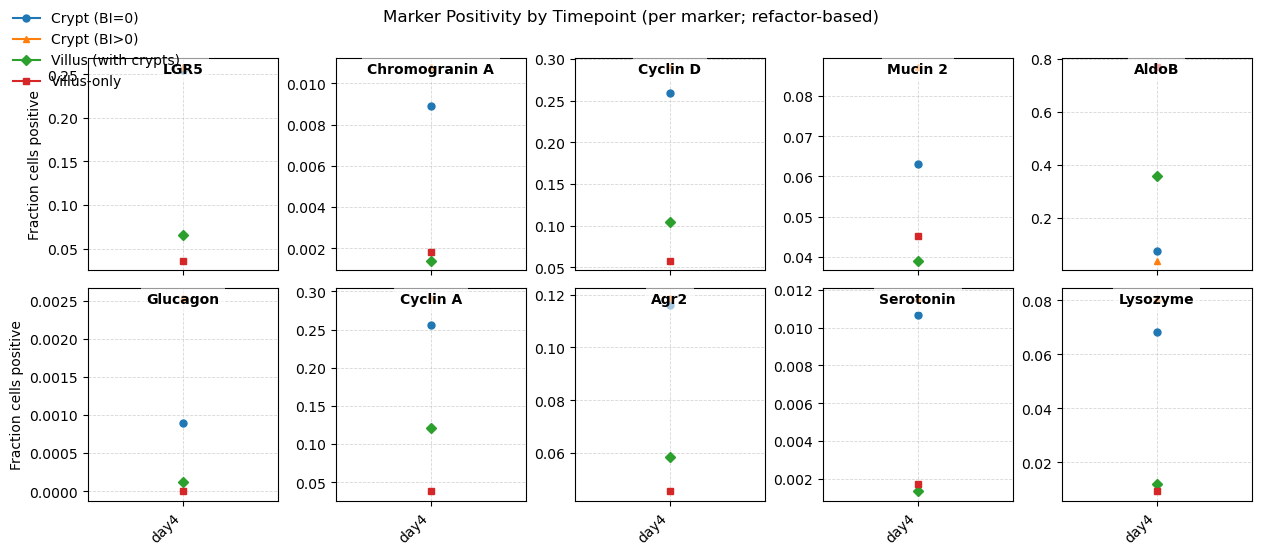

In [15]:
# ----------------------------
# Choose which groups to plot
# ----------------------------
groups = [
    ("Crypt (BI=0)",         dict(patch_type_eq=PT_CRYPT, BI_eq=0.0),                 dict(marker="o")),
    ("Crypt (BI>0)",         dict(patch_type_eq=PT_CRYPT, BI_range=(1e-12, None)),    dict(marker="^")),
    ("Villus (with crypts)", dict(patch_type_eq=PT_VILLUS_WITH),                      dict(marker="D")),
    ("Villus-only",          dict(patch_type_eq=PT_VILLUS_ONLY),                      dict(marker="s")),
]
group_names = [g[0] for g in groups]

# ----------------------------
# Compute time-resolved fractions
# ----------------------------
n_tp = len(timepoints)
M = len(marker_names)

frac_cells_pos_time = np.full((len(groups), n_tp, M), np.nan, dtype=float)  # (G, T, M)
Npatch_time = np.zeros((len(groups), n_tp), dtype=int)

for gi, (_, sel_kwargs, _) in enumerate(groups):
    for tp_idx in range(n_tp):
        m = make_selector(tp_idx_eq=tp_idx, **sel_kwargs)
        _, frac_cells, _, n = aggregate_composition(m)  # frac_cells: (M,)
        frac_cells_pos_time[gi, tp_idx, :] = frac_cells
        Npatch_time[gi, tp_idx] = n

# ----------------------------
# Plot
# ----------------------------
x = np.arange(n_tp)
n_cols = 5
n_rows = int(np.ceil(M / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(2.5 * n_cols, 2.5 * n_rows),
    sharex=True, sharey=False,
    constrained_layout=True
)
axes = np.atleast_1d(axes).reshape(n_rows, n_cols)

for mi in range(M):
    r, c = divmod(mi, n_cols)
    ax = axes[r, c]

    for gi, (gname, _, style) in enumerate(groups):
        ax.plot(
            x,
            frac_cells_pos_time[gi, :, mi],
            label=gname if mi == 0 else None,  # legend only once
            linewidth=1.5,
            markersize=5,
            **style,
        )

    ax.text(
        0.5, 0.98,
        marker_names[mi],
        transform=ax.transAxes,
        ha="center", va="top",
        fontweight="bold", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6),
    )
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(timepoints, rotation=45, ha="right")

    if c == 0:
        ax.set_ylabel("Fraction cells positive")

# hide unused subplots
for idx in range(M, n_rows * n_cols):
    rr, cc = divmod(idx, n_cols)
    axes[rr, cc].axis("off")

# single figure-level legend
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", ncol=1, frameon=False)

fig.suptitle("Marker Positivity by Timepoint (per marker; refactor-based)", y=1.08, fontsize=12)
plt.show()


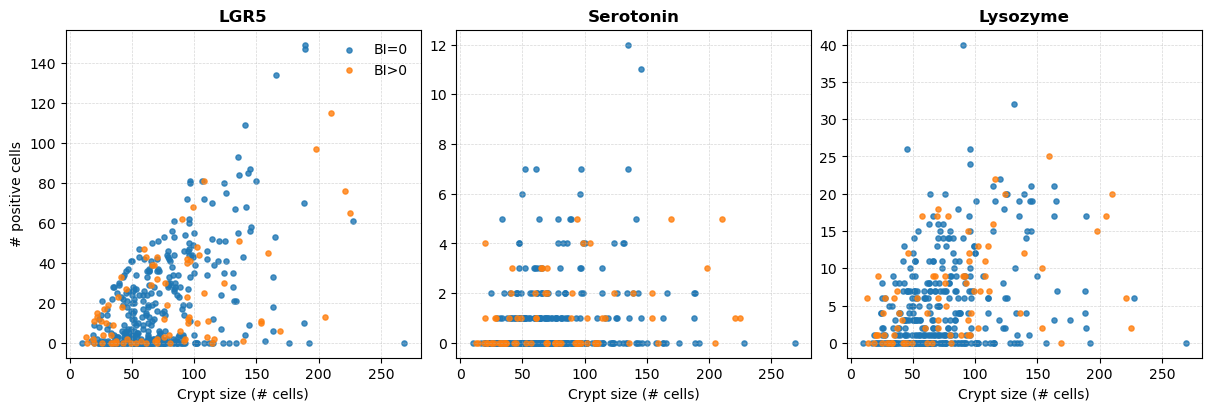

In [16]:
# --- configuration ---
min_positive = 1  # only affects interpretation; we still plot raw #positive cells from patch_poscells

# select crypt rows from the patch table
m_crypt = (patch_type == PT_CRYPT)

sizes   = patch_numcells[m_crypt].astype(int)          # (n_crypts,)
pos_mat = patch_poscells[m_crypt].astype(int)          # (n_crypts, M)
BI_vec  = patch_BI[m_crypt].astype(float)              # (n_crypts,)

# BI groups
m_bi0   = (BI_vec == 0.0)
m_bipos = (BI_vec > 0.0)

# markers to plot
markers = [("LGR5", i_LGR5), ("Serotonin", i_Sero), ("Lysozyme", i_Lyso)]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True, sharex=True, sharey=False)

for ax, (name, idx) in zip(axes, markers):
    y = pos_mat[:, idx]

    # two scatters to color by BI group (avoid colormap overhead + keeps legend simple)
    ax.scatter(sizes[m_bi0],   y[m_bi0],   s=14, alpha=0.8, label="BI=0")
    ax.scatter(sizes[m_bipos], y[m_bipos], s=14, alpha=0.8, label="BI>0")

    ax.set_title(name, fontweight="bold")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    ax.set_xlabel("Crypt size (# cells)")

axes[0].set_ylabel("# positive cells")
axes[0].legend(frameon=False)

plt.show()

## Spatially resolved marker composition in crypts

In [17]:
def coarsen_bins(bin_centers, counts, k):
    """
    Combine bins by summing every k consecutive bins.

    bin_centers: (n_bins,)
    counts: (..., n_bins)
    k: int, number of bins to combine
    """
    if k <= 1:
        return bin_centers, counts

    n_bins = bin_centers.shape[0]
    n_coarse = n_bins // k
    trunc = n_coarse * k

    bin_centers_trunc = bin_centers[:trunc]
    counts_trunc = counts[..., :trunc]

    new_shape = counts_trunc.shape[:-1] + (n_coarse, k)
    counts_block = counts_trunc.reshape(new_shape)
    counts_coarse = counts_block.sum(axis=-1)

    bin_centers_block = bin_centers_trunc.reshape(n_coarse, k)
    bin_centers_coarse = bin_centers_block.mean(axis=1)

    return bin_centers_coarse, counts_coarse

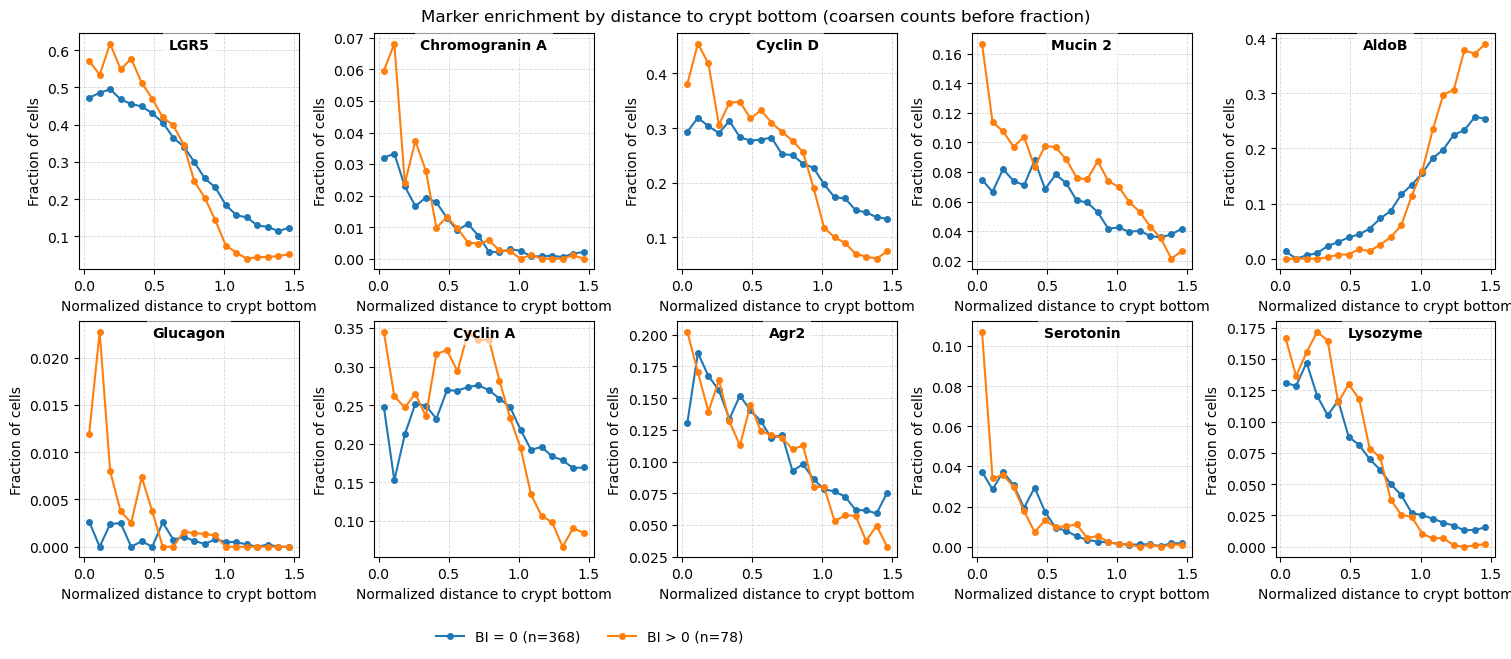

In [18]:
# ============================================================
# USER CONFIG
# ============================================================
k = 4  # coarsening factor

bi_groups = [
    ("BI = 0",        dict(BI_eq=0.0)),
    ("BI > 0",      dict(BI_range=(0.0 + 1e-12, None))),
]

# ============================================================
# Flatten once
# ============================================================
pos_flat = np.concatenate(marker_pos_counts_all, axis=0).astype(float)   # (Ncrypt, M, n_bins)
tot_flat = np.concatenate(marker_cell_counts_all, axis=0).astype(float)  # (Ncrypt, n_bins)
BI_flat  = np.concatenate(BI_all, axis=0).astype(float)                  # (Ncrypt,)

# ============================================================
# Pooled fraction profile with COARSENING BEFORE DIVISION
# ============================================================
def pooled_fraction_profile_coarsened(selector_kwargs, k):
    """
    Returns:
      frac_c: (M, n_bins_coarse) pooled fraction after coarsen: sum(pos_c)/sum(tot_c)
      n:      number of crypts in the group
      x_c:    (n_bins_coarse,) coarsened bin centers
    """
    # BI mask
    if "BI_eq" in selector_kwargs:
        m = (BI_flat == float(selector_kwargs["BI_eq"]))
    elif "BI_range" in selector_kwargs:
        lo, hi = selector_kwargs["BI_range"]
        lo = -np.inf if lo is None else float(lo)
        hi = +np.inf if hi is None else float(hi)
        m = (BI_flat >= lo) & (BI_flat < hi)
    else:
        raise ValueError("selector_kwargs must contain BI_eq or BI_range")

    n = int(np.sum(m))
    if n == 0:
        x_c, _ = coarsen_bins(bin_centers, np.zeros((pos_flat.shape[-1],), float), k)
        frac_nan = np.full((pos_flat.shape[1], x_c.shape[0]), np.nan, dtype=float)
        return frac_nan, 0, x_c

    # sum across crypts FIRST (still fine bins)
    pos_sum = np.nansum(pos_flat[m], axis=0)  # (M, n_bins)
    tot_sum = np.nansum(tot_flat[m], axis=0)  # (n_bins,)

    # coarsen summed counts
    x_c, pos_sum_c = coarsen_bins(bin_centers, pos_sum, k)   # (M, n_bins_coarse)
    _,   tot_sum_c = coarsen_bins(bin_centers, tot_sum, k)   # (n_bins_coarse,)

    # fraction AFTER coarsening
    frac_c = pos_sum_c / np.maximum(tot_sum_c[None, :], 1.0)
    return frac_c, n, x_c

# ============================================================
# Compute group curves (already coarsened)
# ============================================================
group_frac_coarse = []
group_ns = []
bin_centers_coarse = None

for gname, sel in bi_groups:
    frac_c, n, x_c = pooled_fraction_profile_coarsened(sel, k)
    group_frac_coarse.append(frac_c)  # (M, n_bins_coarse)
    group_ns.append(n)
    if bin_centers_coarse is None:
        bin_centers_coarse = x_c

group_frac_coarse = np.stack(group_frac_coarse, axis=0)  # (G, M, n_bins_coarse)

# ============================================================
# Plot
# ============================================================
M = len(marker_names)
n_cols = 5
n_rows = int(np.ceil(M / n_cols))
G = len(bi_groups)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3 * n_cols, 3 * n_rows),
    sharex=False, sharey=False,
    constrained_layout=True
)
axes = np.atleast_1d(axes).reshape(n_rows, n_cols)

for mi in range(M):
    r, c = divmod(mi, n_cols)
    ax = axes[r, c]

    for gi, (gname, _) in enumerate(bi_groups):
        ax.plot(
            bin_centers_coarse,
            group_frac_coarse[gi, mi, :],
            marker="o",
            linewidth=1.5,
            markersize=4,
            label=f"{gname} (n={group_ns[gi]})" if mi == 0 else None
        )

    ax.text(
        0.5, 0.98,
        marker_names[mi],
        transform=ax.transAxes,
        ha="center", va="top",
        fontweight="bold", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6),
    )
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_xlabel("Normalized distance to crypt bottom")
    ax.set_ylabel("Fraction of cells")

# Hide unused subplots
for idx in range(M, n_rows * n_cols):
    rr, cc = divmod(idx, n_cols)
    axes[rr, cc].axis("off")

# Legend (use first subplot)
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper right",
    ncol=min(G, 4),
    bbox_to_anchor=(0.5, -0.02),
    frameon=False,
)

plt.suptitle("Marker enrichment by distance to crypt bottom (coarsen counts before fraction)")
plt.show()


## Plot crypt morphologies

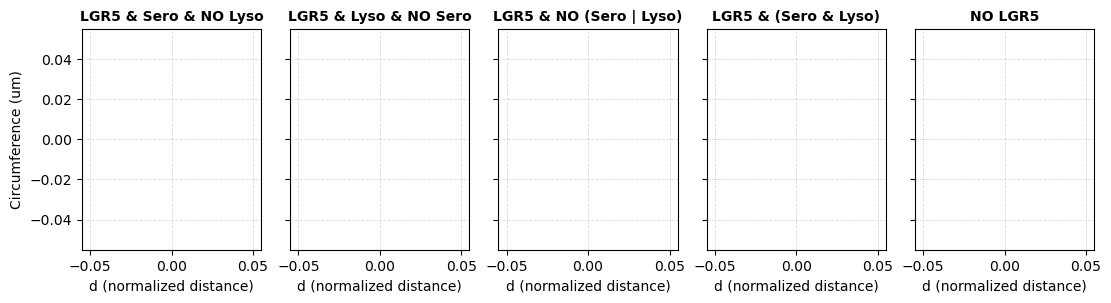

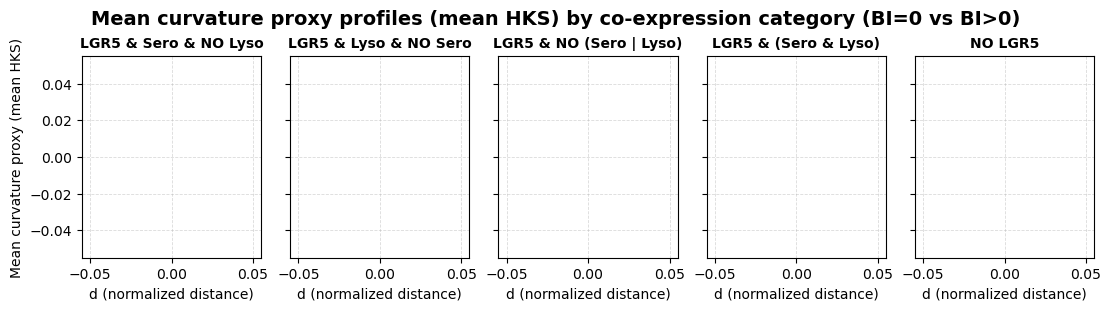

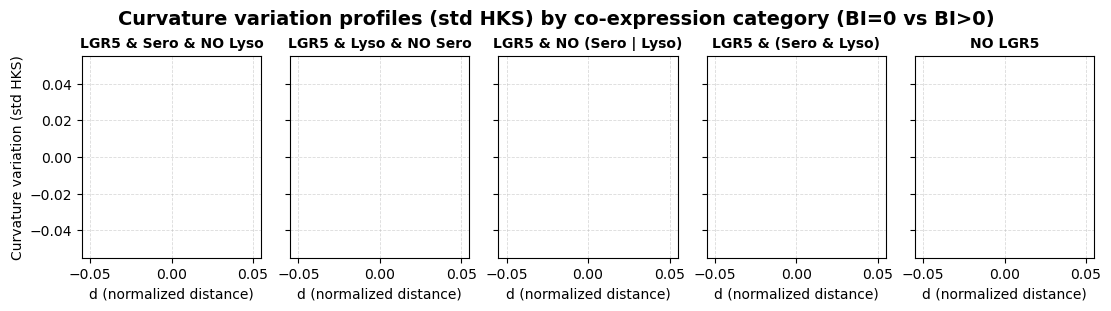

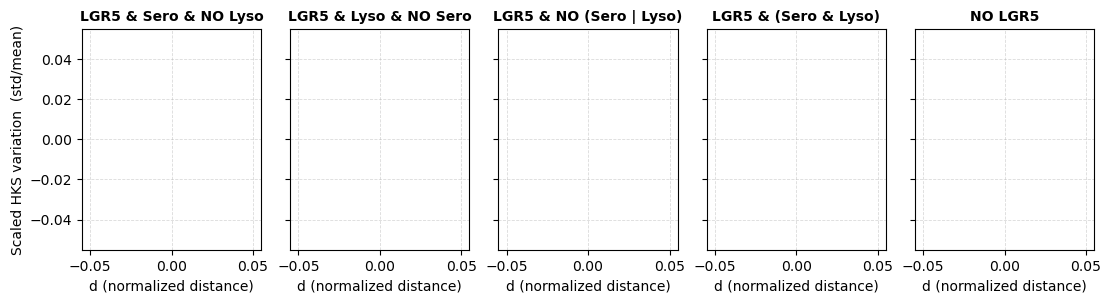

In [19]:

labels_cond_5 = [
    "LGR5 & Sero & NO Lyso",
    "LGR5 & Lyso & NO Sero",
    "LGR5 & NO (Sero | Lyso)",
    "LGR5 & (Sero & Lyso)",
    "NO LGR5",
]

# marker indices
i_LGR5 = marker_names.index("LGR5")
i_Sero = marker_names.index("Serotonin")
i_Lyso = marker_names.index("Lysozyme")

pos_threshold = 1  # used for category assignment

# ============================================================
# Helper: compute mean + SEM across curves (ignoring NaNs)
# ============================================================
def mean_and_sem(curves):
    """
    curves: (N, n_bins)
    returns: mean (n_bins,), sem (n_bins,), n_eff_per_bin (n_bins,)
    """
    curves = np.asarray(curves, float)
    if curves.size == 0:
        return (np.full((bin_centers.size,), np.nan),
                np.full((bin_centers.size,), np.nan),
                np.zeros((bin_centers.size,), dtype=int))
    m = np.nanmean(curves, axis=0)
    n_eff = np.sum(np.isfinite(curves), axis=0)
    sd = np.nanstd(curves, axis=0, ddof=1)
    sem = sd / np.maximum(np.sqrt(n_eff), 1.0)
    sem[n_eff < 2] = np.nan
    return m, sem, n_eff


def safe_divide(a, b, eps=1e-12):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    out = np.full_like(a, np.nan, dtype=float)
    m = np.isfinite(a) & np.isfinite(b) & (np.abs(b) > eps)
    out[m] = a[m] / b[m]
    return out

# ============================================================
# Helper: assign category + BI-group to each crypt, WITHOUT recomputing curves
#   - category comes from markers in patch (graph)
#   - BI-group comes from BI_all traversal order
# ============================================================
def build_crypt_labels_per_timepoint(results, timepoints, BI_all, pos_threshold=1):
    """
    Returns:
      cat_all: list[n_tp] of arrays (Ncrypt_tp,) in {0,1,2,3,4}
      bi_is0_all: list[n_tp] of bool arrays (Ncrypt_tp,) True if BI==0
    """
    cat_all = []
    bi_is0_all = []

    for tp_idx, tp in enumerate(timepoints):
        d = results[tp]
        graphs_all = d.get("cell_graphs_all", [])
        crypts_all = d.get("crypts_all", [])
        if isinstance(crypts_all, np.ndarray):
            crypts_all = crypts_all.tolist()

        BI_tp = np.asarray(BI_all[tp_idx], float)
        bi_ptr = 0

        cats_tp = []
        bi0_tp = []

        for org_idx in range(len(graphs_all)):
            G = graphs_all[org_idx]
            if G is None:
                continue

            # per-cell markers
            markers = np.asarray([G.nodes[n]["markers_bin"] for n in G.nodes], dtype=np.int64)
            if markers is None:
                continue

            crypt_patches = as_patch_list(crypts_all[org_idx] if org_idx < len(crypts_all) else None)
            if not crypt_patches:
                continue

            for patch in crypt_patches:
                patch = set(patch)
                if len(patch) == 0:
                    continue

                if bi_ptr >= BI_tp.size:
                    raise RuntimeError(
                        f"BI_tp exhausted at tp={tp} (tp_idx={tp_idx}). "
                        "Crypt traversal order mismatch vs BI_all construction."
                    )
                BI = float(BI_tp[bi_ptr]); bi_ptr += 1
                bi0 = (BI == 0.0)

                # category index in {0..4}
                cat = assign_coexpression_category(
                    patch, markers,
                    i_LGR5=i_LGR5, i_Sero=i_Sero, i_Lyso=i_Lyso,
                    pos_threshold=pos_threshold
                )

                cats_tp.append(int(cat))
                bi0_tp.append(bool(bi0))

        cats_tp = np.asarray(cats_tp, dtype=int)
        bi0_tp  = np.asarray(bi0_tp, dtype=bool)

        # sanity: should match the number of curves stored
        cat_all.append(cats_tp)
        bi_is0_all.append(bi0_tp)

        # Optional diagnostic:
        n_curves = (np.asarray(crypt_circumferences_all[tp_idx]).shape[0]
                    if len(crypt_circumferences_all[tp_idx]) else 0)
        if cats_tp.size != n_curves:
            print(f"[WARN] tp={tp}: labels={cats_tp.size} but curves={n_curves}. "
                  "If you filtered crypts when computing curves, apply the same filter here.")

    return cat_all, bi_is0_all

# ============================================================
# Helper: flatten per-timepoint arrays consistently
# ============================================================
def flatten_list_of_arrays(list_of_arrays):
    ok = [np.asarray(a) for a in list_of_arrays if a is not None and np.asarray(a).size > 0]
    if not ok:
        return np.empty((0,), dtype=float)
    return np.concatenate(ok, axis=0)

def flatten_profiles(profile_all):
    ok = [np.asarray(a, float) for a in profile_all if a is not None and np.asarray(a).size > 0]
    if not ok:
        return np.empty((0, bin_centers.size), dtype=float)
    return np.concatenate(ok, axis=0)

# ============================================================
# Build labels (category + BI-group) aligned with stored curves
# ============================================================
cat_tp_list, bi0_tp_list = build_crypt_labels_per_timepoint(
    results=results,
    timepoints=timepoints,
    BI_all=BI_all,
    pos_threshold=pos_threshold
)

cat_flat = flatten_list_of_arrays(cat_tp_list).astype(int)           # (Ncrypt,)
bi0_flat = flatten_list_of_arrays(bi0_tp_list).astype(bool)          # (Ncrypt,)

# Flatten stored profiles
C_flat   = flatten_profiles(crypt_circumferences_all)                # (Ncrypt, n_bins)
MU_flat  = flatten_profiles(curv_mean_all)                           # (Ncrypt, n_bins)
STD_flat = flatten_profiles(curv_std_all)                            # (Ncrypt, n_bins)

# Guard: keep only entries where all have matching length (in case of any mismatch)
N = min(cat_flat.size, bi0_flat.size, C_flat.shape[0], MU_flat.shape[0], STD_flat.shape[0])
cat_flat = cat_flat[:N]
bi0_flat = bi0_flat[:N]
C_flat   = C_flat[:N]
MU_flat  = MU_flat[:N]
STD_flat = STD_flat[:N]

# ============================================================
# Plotting helper: 5 subplots, each has BI=0 and BI>0 mean±SEM
# ============================================================
def plot_profiles_by_category_and_BI(profiles, x, title, y_label, labels_cond_5):
    """
    profiles: (Ncrypt, n_bins)
    """
    profiles = np.asarray(profiles, float)
    x = np.asarray(x, float)

    fig, axes = plt.subplots(1, 5, figsize=(11, 3.0), sharex=True, sharey=True, constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for k in range(5):
        ax = axes[k]
        ax.set_title(labels_cond_5[k], fontsize=10, fontweight="bold")

        # BI=0
        m0 = (cat_flat == k) & (bi0_flat == True)
        y0 = profiles[m0]
        mu0, se0, n0 = mean_and_sem(y0)

        # BI>0
        m1 = (cat_flat == k) & (bi0_flat == False)
        y1 = profiles[m1]
        mu1, se1, n1 = mean_and_sem(y1)

        # Plot BI=0
        ax.plot(x, mu0, linewidth=2.0, label=f"BI=0")
        ax.fill_between(x, mu0 - se0, mu0 + se0, alpha=0.22, linewidth=0)

        # Plot BI>0
        ax.plot(x, mu1, linewidth=2.0, label=f"BI>0")
        ax.fill_between(x, mu1 - se1, mu1 + se1, alpha=0.22, linewidth=0)

        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.45)
        ax.set_xlabel("d (normalized distance)")
        if k == 0:
            ax.set_ylabel(y_label)

    # legend once
    handles, labels = axes[0].get_legend_handles_labels()
    # fig.legend(handles, labels, frameon=False, ncol=1, loc="upper right")
    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.show()

# ============================================================
# FIGURE 1: Mean circumference curves ± SEM
# ============================================================
plot_profiles_by_category_and_BI(
    profiles=C_flat*10,
    x=bin_centers,
    title="", # "Mean crypt circumference profiles by co-expression category (BI=0 vs BI>0)",
    y_label="Circumference (um)",
    labels_cond_5=labels_cond_5,
)

# ============================================================
# FIGURE 2: Mean curvature (HKS mean) curves ± SEM
# ============================================================
plot_profiles_by_category_and_BI(
    profiles=MU_flat,
    x=bin_centers,
    title="Mean curvature proxy profiles (mean HKS) by co-expression category (BI=0 vs BI>0)",
    y_label="Mean curvature proxy (mean HKS)",
    labels_cond_5=labels_cond_5,
)

# ============================================================
# FIGURE 3: Curvature variation curves ± SEM
# ============================================================
plot_profiles_by_category_and_BI(
    profiles=STD_flat,
    x=bin_centers,
    title="Curvature variation profiles (std HKS) by co-expression category (BI=0 vs BI>0)",
    y_label="Curvature variation (std HKS)",
    labels_cond_5=labels_cond_5,
)

# ============================================================
# FIGURE: scaled curvature variation profiles (std/mean)
# ============================================================
scaled_var_flat = safe_divide(STD_flat, MU_flat, eps=1e-12)  # (Ncrypt, n_bins)

plot_profiles_by_category_and_BI(
    profiles=scaled_var_flat,
    x=bin_centers,
    title="",#"Scaled curvature variation profiles (std(HKS)/mean(HKS)) by co-expression category (BI=0 vs BI>0)",
    y_label="Scaled HKS variation  (std/mean)",
    labels_cond_5=labels_cond_5,
)


## Create and plot "morphospaces"

In [20]:
from matplotlib.lines import Line2D

# BI_all, CI_all, EI_all: lists per timepoint (each element = array of crypt values)
# timepoints: list of timepoint labels (same order as BI_all, CI_all, EI_all)

# ---- collect data per timepoint ----
data = []
for tp_idx, tp in enumerate(timepoints):
    BI_tp = np.asarray(BI_all[tp_idx], float).ravel()
    CI_tp = np.asarray(CI_all[tp_idx], float).ravel()
    EI_tp = np.asarray(EI_all[tp_idx], float).ravel()

    m = np.isfinite(BI_tp) & np.isfinite(CI_tp) & np.isfinite(EI_tp)
    if np.any(m):
        data.append((tp, BI_tp[m], CI_tp[m], EI_tp[m]))

# ---- colors for timepoints ----
cmap = plt.get_cmap("tab10")  # good for categorical timepoints
colors = {tp: cmap(i % 10) for i, tp in enumerate(timepoints)}

# ---- plot ----
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

for tp, BI_tp, CI_tp, EI_tp in data:
    col = colors[tp]

    # (BI, CI)
    axes[0].scatter(BI_tp+1e-7, CI_tp, s=15, alpha=0.25, color=col)

    # (BI, EI)
    axes[1].scatter(BI_tp+1e-7, EI_tp, s=15, alpha=0.25, color=col)

    # (CI, EI)
    axes[2].scatter(CI_tp, EI_tp, s=15, alpha=0.25, color=col)

# ---- formatting ----
axes[0].set_xlabel("BI")
axes[0].set_ylabel("CI")
axes[0].set_title("(BI, CI)")
# axes[0].set_xlim(0, 1)
# axes[0].set_ylim(0, 1)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

axes[1].set_xlabel("BI")
axes[1].set_ylabel("EI")
axes[1].set_title("(BI, EI)")
# axes[1].set_xlim(0, 1)
axes[1].set_xscale('log')
axes[1].grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

axes[2].set_xlabel("CI")
axes[2].set_ylabel("EI")
axes[2].set_title("(CI, EI)")
# axes[2].set_xlim(0, 1)
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

# ---- legend ----
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label=str(tp),
           markerfacecolor=colors[tp], markersize=8, alpha=0.8)
    for tp in timepoints
]

fig.legend(
    handles=legend_handles,
    title="Timepoint",
    loc="upper right",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False
)

plt.suptitle("Crypt morphospace colored by timepoint", fontsize=14)
plt.show()

ValueError: operands could not be broadcast together with shapes (446,) (0,) 

N metrics: 199
N crypt cats: 199


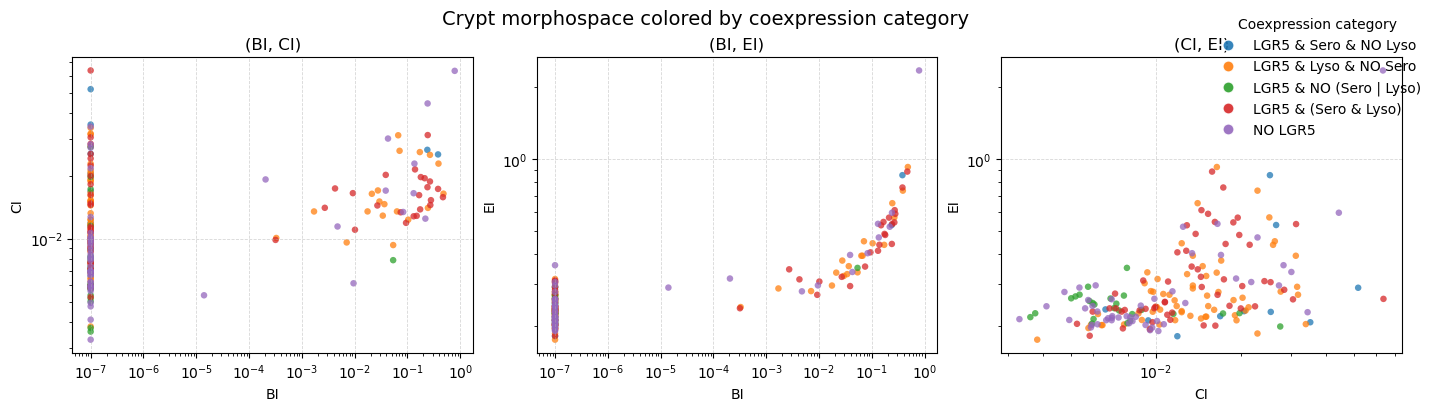

In [ ]:
# ------------------------------------------------------------
# Flatten metrics (same as before)
# ------------------------------------------------------------
BI_flat = np.concatenate([np.asarray(x, float).ravel() for x in BI_all if len(x)])
CI_flat = np.concatenate([np.asarray(x, float).ravel() for x in CI_all if len(x)])
EI_flat = np.concatenate([np.asarray(x, float).ravel() for x in EI_all if len(x)])

BI = np.asarray(BI_flat, float).ravel() + 1e-7
CI = np.asarray(CI_flat, float).ravel()
EI = np.asarray(EI_flat, float).ravel()

# ------------------------------------------------------------
# Categories from the refactor patch table
#   - Use only crypt rows
#   - New category names (5 categories, last = NO LGR5)
# ------------------------------------------------------------
m_crypt = (patch_type == PT_CRYPT)
cat = np.asarray(patch_cat5[m_crypt], int).ravel()

cat_names_5 = [
    "LGR5 & Sero & NO Lyso",
    "LGR5 & Lyso & NO Sero",
    "LGR5 & NO (Sero | Lyso)",
    "LGR5 & (Sero & Lyso)",
    "NO LGR5",
]

# Sanity check: these should match
print("N metrics:", BI.size)
print("N crypt cats:", cat.size)
if BI.size != cat.size:
    print("[WARN] BI/CI/EI flattening does not match crypt patch count.")
    print("       This plot assumes 1 BI/CI/EI entry per crypt patch in the same traversal order.")
    # If this warning triggers, we should instead store crypt-level categories aligned to BI_all.

# ------------------------------------------------------------
# Colors
# ------------------------------------------------------------
cmap = plt.get_cmap("tab10")
cat_colors = {k: cmap(k) for k in range(5)}

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

pairs = [
    (BI, CI, "BI", "CI", "(BI, CI)"),
    (BI, EI, "BI", "EI", "(BI, EI)"),
    (CI, EI, "CI", "EI", "(CI, EI)"),
]

for ax, (x, y, xl, yl, title) in zip(axes, pairs):
    for k in range(5):
        mk = (cat == k)
        if np.any(mk):
            ax.scatter(x[mk], y[mk], s=22, alpha=0.75, color=cat_colors[k], edgecolors="none")

    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(title)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

    ax.set_xscale("log")
    ax.set_yscale("log")

legend_handles = [
    Line2D([0], [0], marker="o", color="w", label=cat_names_5[k],
           markerfacecolor=cat_colors[k], markersize=8, alpha=0.9)
    for k in range(5)
]

fig.legend(
    handles=legend_handles,
    title="Coexpression category",
    loc="upper right",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False
)

plt.suptitle("Crypt morphospace colored by coexpression category", fontsize=14)
plt.show()



Total crypts (raw): 199
Dropping curves:
  nonfinite: 0
  all_zero : 0
  >25% zeros: 0
  total dropped: 0
Total crypts (kept): 199
Dropping due to nonfinite features: 0
Final crypt count for clustering: 199
Silhouette score: 0.4720873201365917


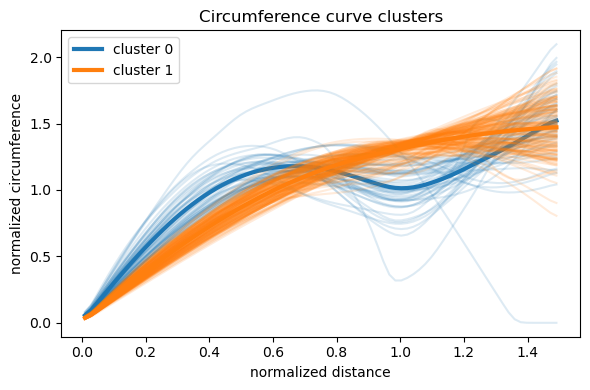

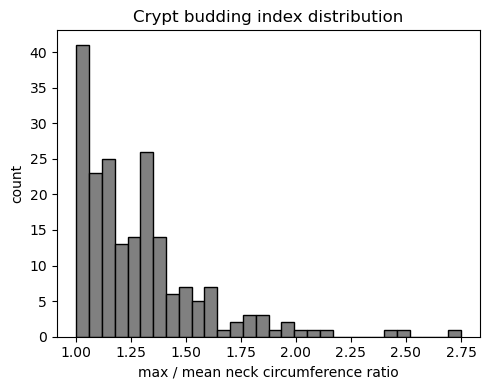

Budding index summary:
  mean = 1.2915754261452965
  std  = 0.2854068233087935
  min  = 1.0027641595680974
  max  = 2.748849875586815


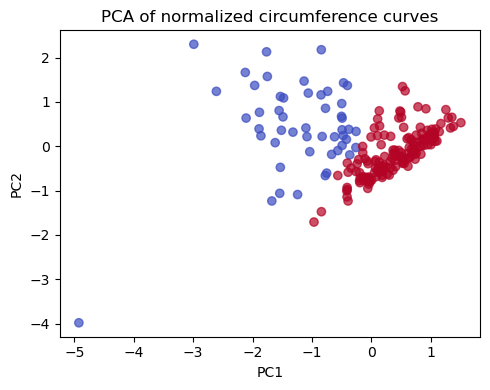

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ============================================================
# 1) Collect curves across timepoints
# ============================================================

curves = []
curve_meta = []  # (timepoint_idx, crypt_idx)

for tp_idx, C_tp in enumerate(crypt_circumferences_all):
    C_tp = np.asarray(C_tp)
    if C_tp.size == 0:
        continue
    for k in range(C_tp.shape[0]):
        curves.append(C_tp[k])
        curve_meta.append((tp_idx, k))

curves = np.asarray(curves, dtype=float)  # (N_crypts, n_bins)
print("Total crypts (raw):", curves.shape[0])

s = bin_centers

# ============================================================
# 2) Basic cleaning: remove pathological curves
# ============================================================

# A curve is "bad" if:
# - any non-finite
# - too many near-zeros (likely "no contour" bins)
# - nearly all zeros (completely invalid)
eps0 = 1e-10
nonfinite = ~np.isfinite(curves).all(axis=1)
frac_zero = np.mean(curves <= eps0, axis=1)
all_zero  = np.all(curves <= eps0, axis=1)

# tweak thresholds if you want
bad = nonfinite | all_zero | (frac_zero > 0.25)

print("Dropping curves:")
print("  nonfinite:", int(np.sum(nonfinite)))
print("  all_zero :", int(np.sum(all_zero)))
print("  >25% zeros:", int(np.sum(frac_zero > 0.25)))
print("  total dropped:", int(np.sum(bad)))

curves = curves[~bad]
curve_meta = [m for m, keep in zip(curve_meta, ~bad) if keep]

print("Total crypts (kept):", curves.shape[0])

# Optional: lift tiny values away from 0 (prevents division blowups)
curves = np.maximum(curves, eps0)

# ============================================================
# 3) Normalize + smooth (shape-only)
# ============================================================

curves_norm = curves / np.nanmean(curves, axis=1, keepdims=True)
curves_norm = gaussian_filter1d(curves_norm, sigma=1.0, axis=1)

# ============================================================
# 4) Feature extraction (safe denominators)
# ============================================================

def extract_features(curve, eps=1e-8):
    bottom = float(np.mean(curve[s < 0.2]))
    neck   = float(np.mean(curve[(s > 0.8) & (s < 1.0)]))

    bottom = max(bottom, eps)
    neck   = max(neck, eps)

    bulge_amp    = float(np.max(curve) / bottom)
    constriction = float(neck / bottom)

    idx = np.where((s > 0.6) & (s < 1.0))[0]
    if idx.size >= 2:
        slope = float(np.polyfit(s[idx], curve[idx], 1)[0])
        curvature = float(np.mean(np.gradient(np.gradient(curve[idx]))))
    else:
        slope = np.nan
        curvature = np.nan

    return np.array([constriction, bulge_amp, slope, curvature], dtype=float)

X_feat = np.vstack([extract_features(c) for c in curves_norm])

# remove rows with nan/inf (e.g. from tiny idx ranges etc)
good_feat = np.isfinite(X_feat).all(axis=1)
print("Dropping due to nonfinite features:", int(np.sum(~good_feat)))

curves_norm = curves_norm[good_feat]
X_feat = X_feat[good_feat]
curve_meta = [m for m, keep in zip(curve_meta, good_feat) if keep]

print("Final crypt count for clustering:", X_feat.shape[0])

# ============================================================
# 5) Cluster (bulged vs budded)
# ============================================================

X = StandardScaler().fit_transform(X_feat)
kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(X)
print("Silhouette score:", silhouette_score(X, labels))

# ============================================================
# 6) Plot clusters (curves)
# ============================================================

plt.figure(figsize=(6, 4))
for k in [0, 1]:
    cluster_curves = curves_norm[labels == k]
    plt.plot(s, cluster_curves.T, color=f"C{k}", alpha=0.15)
    plt.plot(s, cluster_curves.mean(axis=0), color=f"C{k}", linewidth=3, label=f"cluster {k}")
plt.xlabel("normalized distance")
plt.ylabel("normalized circumference")
plt.title("Circumference curve clusters")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 7) Budding index = max / mean(neck) (safe)
# ============================================================

neck_mask = (s > 0.8) & (s < 1.0)
max_circ = np.max(curves_norm, axis=1)
mean_neck = np.mean(curves_norm[:, neck_mask], axis=1)
mean_neck = np.maximum(mean_neck, 1e-8)

budding_index = max_circ / mean_neck

plt.figure(figsize=(5, 4))
plt.hist(budding_index, bins=30, color="gray", edgecolor="black")
plt.xlabel("max / mean neck circumference ratio")
plt.ylabel("count")
plt.title("Crypt budding index distribution")
plt.tight_layout()
plt.show()

print("Budding index summary:")
print("  mean =", float(np.mean(budding_index)))
print("  std  =", float(np.std(budding_index)))
print("  min  =", float(np.min(budding_index)))
print("  max  =", float(np.max(budding_index)))

# ============================================================
# 8) Optional PCA sanity check
# ============================================================

pca = PCA(n_components=3)
X_pca = pca.fit_transform(curves_norm)

plt.figure(figsize=(5, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="coolwarm", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of normalized circumference curves")
plt.tight_layout()
plt.show()


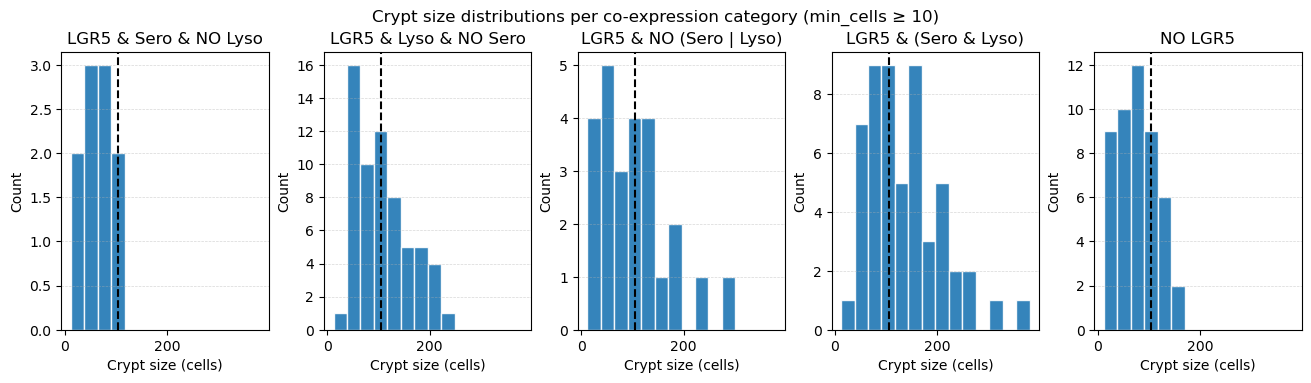

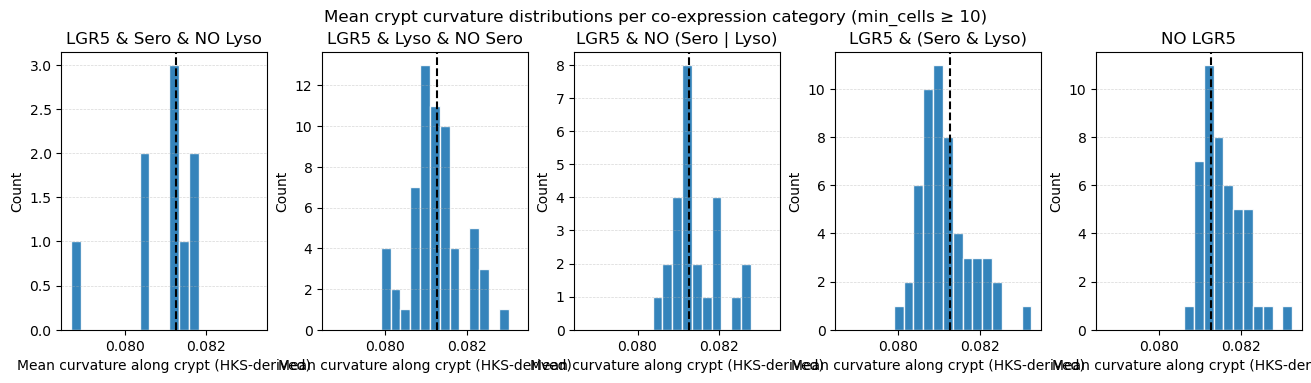

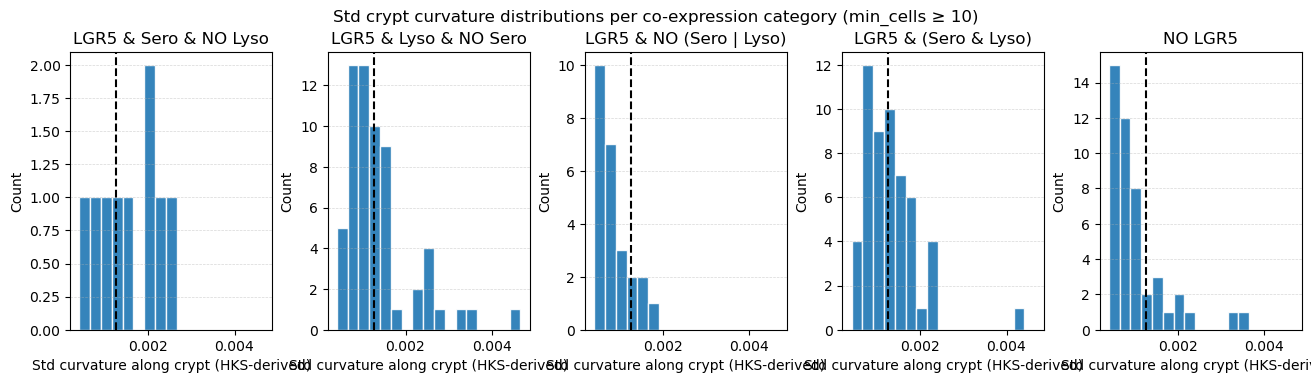

In [ ]:
# --- configuration ---
min_cells = 10
labels_cond_5 = [
    "LGR5 & Sero & NO Lyso",
    "LGR5 & Lyso & NO Sero",
    "LGR5 & NO (Sero | Lyso)",
    "LGR5 & (Sero & Lyso)",
    "NO LGR5",
]

# ------------------------------------------------------------
# Flatten curvature summaries across timepoints
#   We'll derive a simple per-crypt scalar mean/std by averaging
#   the profile over s (ignoring NaNs).
# ------------------------------------------------------------
curv_mean_flat = np.concatenate([np.asarray(x, float) for x in curv_mean_all if len(x)], axis=0)  # (Ncrypt, n_bins)
curv_std_flat  = np.concatenate([np.asarray(x, float) for x in curv_std_all  if len(x)], axis=0)  # (Ncrypt, n_bins)

# Per-crypt scalars (average along s)
crypt_curv_mean_scalar = np.nanmean(curv_mean_flat, axis=1)  # (Ncrypt,)
crypt_curv_std_scalar  = np.nanmean(curv_std_flat, axis=1)   # (Ncrypt,)

# ------------------------------------------------------------
# Categories + sizes from patch table (crypt rows only)
# ------------------------------------------------------------
m_crypt = (patch_type == PT_CRYPT)
crypt_sizes = patch_numcells[m_crypt].astype(int)     # (Ncrypt,)
crypt_cat5  = patch_cat5[m_crypt].astype(int)         # (Ncrypt,)

# Keep only sufficiently large crypts
m_big = (crypt_sizes >= min_cells)

crypt_sizes = crypt_sizes[m_big]
crypt_cat5  = crypt_cat5[m_big]
crypt_curv_mean_scalar = crypt_curv_mean_scalar[m_big]
crypt_curv_std_scalar  = crypt_curv_std_scalar[m_big]

# ------------------------------------------------------------
# Split into lists per category (for easy hist plotting)
# ------------------------------------------------------------
K = 5
size_by_cond      = [crypt_sizes[crypt_cat5 == ci] for ci in range(K)]
mean_curv_by_cond = [crypt_curv_mean_scalar[crypt_cat5 == ci] for ci in range(K)]
std_curv_by_cond  = [crypt_curv_std_scalar[crypt_cat5 == ci] for ci in range(K)]

# ============================================================
# Plot helpers (same idea as your originals, but compact)
# ============================================================

def _finite(x):
    x = np.asarray(x, float).ravel()
    return x[np.isfinite(x)]

def _robust_bins(x, bins="auto", clip_q=(1, 99)):
    x = _finite(x)
    if x.size == 0:
        return None
    lo, hi = np.percentile(x, clip_q)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = np.min(x), np.max(x)
        if hi <= lo:
            hi = lo + 1e-6
    x_clip = x[(x >= lo) & (x <= hi)]
    if x_clip.size < 5:
        x_clip = x
    return np.histogram_bin_edges(x_clip, bins=bins)

def plot_hists_per_category(values_by_cat, labels, xlabel, suptitle, bins="auto", robust=True):
    all_vals = _finite(np.concatenate([_finite(v) for v in values_by_cat if len(v)], axis=0)) \
        if any(len(v) for v in values_by_cat) else np.array([], float)

    if all_vals.size == 0:
        print("No data for:", suptitle)
        return

    edges = _robust_bins(all_vals, bins=bins) if robust else np.histogram_bin_edges(all_vals, bins=bins)

    fig, axes = plt.subplots(1, len(labels), figsize=(2.6*len(labels), 3.5), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    global_mean = float(np.mean(all_vals))
    for ci, ax in enumerate(axes):
        x = _finite(values_by_cat[ci])
        ax.hist(x, bins=edges, edgecolor="white", alpha=0.9)
        ax.set_title(labels[ci])
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Count")
        ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
        ax.axvline(global_mean, color="k", linestyle="--")

    fig.suptitle(suptitle, y=1.05)
    plt.show()

# ============================================================
# 1) Crypt size distributions
# ============================================================
plot_hists_per_category(
    size_by_cond,
    labels_cond_5,
    xlabel="Crypt size (cells)",
    suptitle=f"Crypt size distributions per co-expression category (min_cells ≥ {min_cells})",
    bins="auto",
    robust=False,  # sizes are typically fine without robust clipping
)

# ============================================================
# 2) Mean curvature distributions (proxy)
# ============================================================
plot_hists_per_category(
    mean_curv_by_cond,
    labels_cond_5,
    xlabel="Mean curvature along crypt (HKS-derived)",
    suptitle=f"Mean crypt curvature distributions per co-expression category (min_cells ≥ {min_cells})",
    bins="auto",
    robust=True,
)

# ============================================================
# 3) Std curvature distributions (proxy)
# ============================================================
plot_hists_per_category(
    std_curv_by_cond,
    labels_cond_5,
    xlabel="Std curvature along crypt (HKS-derived)",
    suptitle=f"Std crypt curvature distributions per co-expression category (min_cells ≥ {min_cells})",
    bins="auto",
    robust=True,
)


/home/fmoller/miniforge3/envs/SphericalHarmonics/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



Built feature matrix X: (199, 212)
Finite BI: 1.0  | categories: {-1: 199, 0: 0, 1: 0, 2: 0, 3: 0}


/home/fmoller/miniforge3/envs/SphericalHarmonics/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP embedding: (199, 2)


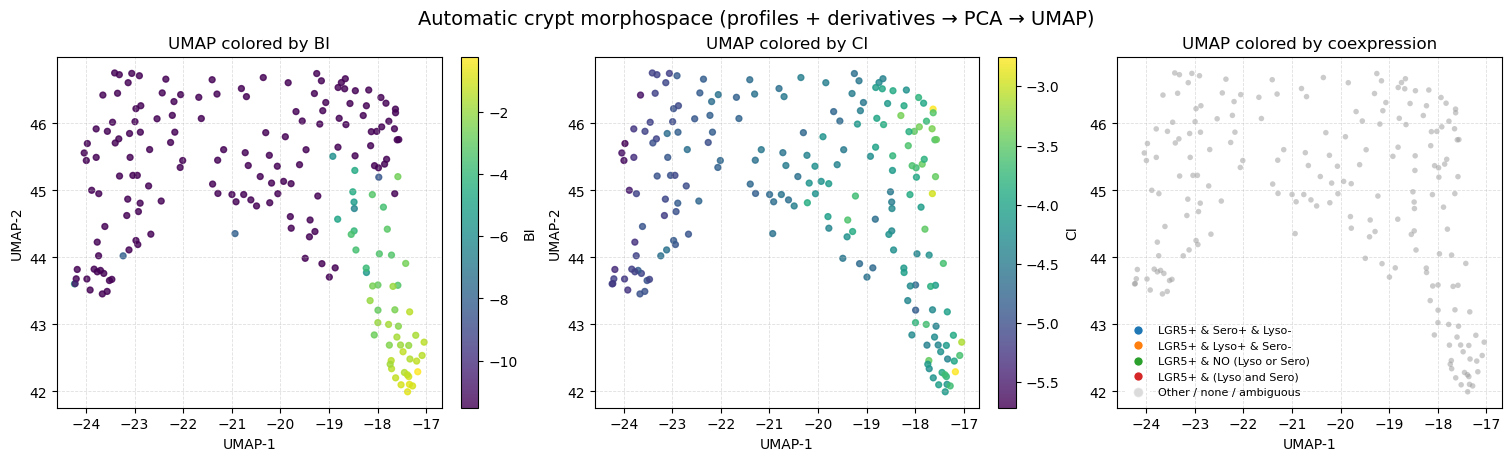

In [ ]:
# ============================================================
# Automatic morphospace from crypt profiles:
#   C'(s)=C(s)/C(1) on s∈[0,1]
#   σ'(s)=σ(s)/μ(s) on s∈[0,1]
# Features: profiles + 1st/2nd derivatives (after smoothing)
# Pipeline: Standardize -> PCA -> UMAP
# Plots: UMAP colored by BI, coexpression category, timepoint
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import umap  # pip install umap-learn
from matplotlib.lines import Line2D

from scipy.signal import savgol_filter
import numpy as np

def _profile_features_fixed_grid(s_grid, y, window=9, poly=3):
    """
    Return [y_smooth, dy/ds, d2y/ds2] on a FIXED s_grid (same length for all crypts).
    - Interpolates y onto s_grid if needed.
    - Fills NaNs by interpolation.
    - Applies SavGol smoothing then finite-difference derivatives.

    s_grid: (N,) fixed grid (e.g. s01)
    y:      (N,) values on the same grid (may contain NaNs)
    """
    s_grid = np.asarray(s_grid, float)
    y = np.asarray(y, float)

    if s_grid.ndim != 1 or y.ndim != 1 or s_grid.size != y.size:
        raise ValueError("s_grid and y must be 1D and the same length.")

    # require at least a few finite points
    m = np.isfinite(y)
    if np.sum(m) < 5:
        return None

    # fill NaNs by interpolation on the fixed grid
    y_fill = y.copy()
    y_fill[~m] = np.interp(s_grid[~m], s_grid[m], y[m])

    # SavGol params (ensure valid)
    wl = int(window)
    if wl % 2 == 0:
        wl += 1
    wl = min(wl, s_grid.size if s_grid.size % 2 == 1 else s_grid.size - 1)
    wl = max(wl, 5)
    po = int(poly)
    po = min(po, wl - 2)

    ys = savgol_filter(y_fill, window_length=wl, polyorder=po, mode="interp")

    dy = np.gradient(ys, s_grid)
    d2y = np.gradient(dy, s_grid)

    return np.concatenate([ys, dy, d2y])



def _profile_features_nosmooth(s_grid, y):
    """
    Return [y, dy/ds, d2y/ds2] on a fixed grid WITHOUT smoothing.

    s_grid: (N,) fixed s-grid (e.g. s01)
    y:      (N,) values on the same grid (may contain NaNs)
    """
    s_grid = np.asarray(s_grid, float)
    y = np.asarray(y, float)

    if s_grid.ndim != 1 or y.ndim != 1 or s_grid.size != y.size:
        raise ValueError("s_grid and y must be 1D and the same length.")

    # require enough finite points
    m = np.isfinite(y)
    if np.sum(m) < 5:
        return None

    # fill NaNs by linear interpolation on the fixed grid
    y_fill = y.copy()
    y_fill[~m] = np.interp(s_grid[~m], s_grid[m], y[m])

    # first derivative
    dy = np.gradient(y_fill, s_grid)

    # second derivative
    d2y = np.gradient(dy, s_grid)

    return np.concatenate([y_fill, dy])


# ----------------------------
# Helper: robust y(s=1)
# ----------------------------
def _value_at_1(s, y, target=1.0):
    s = np.asarray(s, float)
    y = np.asarray(y, float)
    m = np.isfinite(s) & np.isfinite(y)
    if np.sum(m) < 2:
        return np.nan
    s0 = s[m]; y0 = y[m]
    o = np.argsort(s0)
    s0 = s0[o]; y0 = y0[o]
    if target <= s0[0]:
        return float(y0[0])
    if target >= s0[-1]:
        return float(y0[-1])
    return float(np.interp(target, s0, y0))


# ----------------------------
# Helper: build features for one profile
# ----------------------------
def _profile_features(s, y, window=9, poly=3):
    """
    Smooth y(s) with SavGol, then return [y_smooth, dy/ds, d2y/ds2] concatenated.
    """
    s = np.asarray(s, float)
    y = np.asarray(y, float)

    # fill NaNs in y by linear interpolation (on s)
    m = np.isfinite(s) & np.isfinite(y)
    if np.sum(m) < 5:
        return None

    s0 = s[m]
    y0 = y[m]
    o = np.argsort(s0)
    s0 = s0[o]
    y0 = y0[o]

    yfill = np.interp(s0, s0, y0)  # already finite & sorted

    wl = int(window)
    if wl % 2 == 0:
        wl += 1
    wl = min(wl, len(s0) if len(s0) % 2 == 1 else len(s0) - 1)
    wl = max(wl, 5)
    po = int(poly)
    po = min(po, wl - 2)

    ys = savgol_filter(yfill, window_length=wl, polyorder=po, mode="interp")

    dy = np.gradient(ys, s0)
    d2y = np.gradient(dy, s0)

    return np.concatenate([ys, dy, d2y])


# ----------------------------
# Collect per-crypt data into a feature matrix X
# ----------------------------
# Inputs expected from your ensemble analysis:
# - timepoints (list)
# - bin_centers (1D)
# - crypt_circumferences_adj_all : list length n_tp, each (n_crypts_tp, n_bins)  (neck aligned at s=1)
# - curv_mean_all, curv_std_all  : list length n_tp, each (n_crypts_tp, n_bins)
# - BI_all : list length n_tp, each (n_crypts_tp,)
# - coexpression categories:
#     either:
#       (A) coexpression_crypt_all (list per timepoint, each (n_crypts_tp,) int in {0,1,2,3} or -1)
#     or:
#       (B) crypt_cat_idx, crypt_tp_idx from your prototype loop (flat arrays)
#
# This code supports BOTH:
#   - If coexpression_crypt_all exists, use it.
#   - Else if crypt_cat_idx/crypt_tp_idx exist, try to align by timepoint counts (best-effort).
#     (Recommended: store coexpression_crypt_all during the main loop for perfect alignment.)

s = np.asarray(bin_centers, float)
mask_s = np.isfinite(s) & (s >= 0.0) & (s <= 1.0)
s01 = s[mask_s]

# smoothing params (tuned for ~75-80 points)
SG_WINDOW = 4
SG_POLY = 3

X_rows = []
BI_vec = []
CI_vec = []
tp_vec = []
cat_vec = []

# category names/colors (same as before)
cat_names = [
    "LGR5+ & Sero+ & Lyso-",
    "LGR5+ & Lyso+ & Sero-",
    "LGR5+ & NO (Lyso or Sero)",
    "LGR5+ & (Lyso and Sero)",
]
cmap_cat = plt.get_cmap("tab10")
cat_colors = {k: cmap_cat(k) for k in range(4)}
cat_colors[-1] = (0.6, 0.6, 0.6, 0.35)

# Determine where to fetch coexpression categories from
use_coexp_per_tp = "coexpression_crypt_all" in globals()

# If only flat cat arrays exist, we will consume them by timepoint in order (best-effort)
cat_flat = None
cat_tp_flat = None
if (not use_coexp_per_tp) and ("crypt_cat_idx" in globals()) and ("crypt_tp_idx" in globals()):
    cat_flat = np.asarray(crypt_cat_idx, int)
    cat_tp_flat = np.asarray(crypt_tp_idx, int)

cat_flat_ptr = 0

for tp_idx, tp in enumerate(timepoints):
    C_tp = np.asarray(crypt_circumferences_all[tp_idx], float)  # (n_crypts, n_bins)
    mu_tp = np.asarray(curv_mean_all[tp_idx], float)
    sd_tp = np.asarray(curv_std_all[tp_idx], float)
    BI_tp = np.asarray(BI_all[tp_idx], float).ravel()
    CI_tp = np.asarray(CI_all[tp_idx], float).ravel()


    n_crypts = min(C_tp.shape[0], mu_tp.shape[0], sd_tp.shape[0], BI_tp.shape[0])
    if n_crypts == 0:
        continue

    # categories for this timepoint
    if use_coexp_per_tp:
        cat_tp = np.asarray(crypt_cat_idx[tp_idx], int).ravel()
        if cat_tp.size < n_crypts:
            # pad with -1
            cat_tp = np.pad(cat_tp, (0, n_crypts - cat_tp.size), constant_values=-1)
        cat_tp = cat_tp[:n_crypts]
    elif cat_flat is not None:
        # best-effort: take categories with matching tp_idx in sequence
        # (works if your prototype loop iterated timepoints in the same order)
        idxs = np.where(cat_tp_flat == tp_idx)[0]
        # If that doesn't exist reliably, fall back to sequential consumption:
        if idxs.size > 0:
            cat_tp = cat_flat[idxs]
            # If mismatched count, trim/pad
            if cat_tp.size < n_crypts:
                cat_tp = np.pad(cat_tp, (0, n_crypts - cat_tp.size), constant_values=-1)
            cat_tp = cat_tp[:n_crypts]
        else:
            cat_tp = np.full(n_crypts, -1, dtype=int)
    else:
        cat_tp = np.full(n_crypts, -1, dtype=int)

    for j in range(n_crypts):
        C = C_tp[j, :]
        mu = mu_tp[j, :]
        sd = sd_tp[j, :]

        C01 = C[mask_s]
        mu01 = mu[mask_s]
        sd01 = sd[mask_s]

        # ---- Feature 1: C'(s) = C(s) / C(1) ----
        C1 = _value_at_1(s01, C01, target=1.0)
        if not (np.isfinite(C1) and C1 > 1e-12):
            continue
        Cp = C01 / C1

        # ---- Feature 2: sigma'(s) = sigma(s) / mu(s) ----
        # robust division
        denom = np.asarray(mu01, float)
        sigp = np.full_like(sd01, np.nan, dtype=float)
        good = np.isfinite(sd01) & np.isfinite(denom) & (np.abs(denom) > 1e-12)
        sigp[good] = sd01[good] / denom[good]

        # smooth & derivatives for both profiles
        # f1 = _profile_features_fixed_grid(s01, Cp, window=SG_WINDOW, poly=SG_POLY)
        # f2 = _profile_features_fixed_grid(s01, sigp, window=SG_WINDOW, poly=SG_POLY)
        f1 = _profile_features_nosmooth(s01, Cp)
        f2 = _profile_features_nosmooth(s01, sigp)


        if (f1 is None) or (f2 is None):
            continue

        # concatenate features
        x = np.concatenate([f1, f2])

        if not np.all(np.isfinite(x)):
            continue

        X_rows.append(x)
        BI_vec.append(float(BI_tp[j]))
        CI_vec.append(float(CI_tp[j]))
        tp_vec.append(tp_idx)
        cat_vec.append(int(cat_tp[j]))

X = np.asarray(X_rows, float)
BI_vec = np.asarray(BI_vec, float)
CI_vec = np.asarray(CI_vec, float)
tp_vec = np.asarray(tp_vec, int)
cat_vec = np.asarray(cat_vec, int)

print("Built feature matrix X:", X.shape)
print("Finite BI:", np.isfinite(BI_vec).mean(), " | categories:", {k:int(np.sum(cat_vec==k)) for k in [-1,0,1,2,3]})

# ----------------------------
# Standardize -> PCA -> UMAP
# ----------------------------
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

n_pca = min(20, Xz.shape[1], Xz.shape[0]-1 if Xz.shape[0] > 1 else 1)
pca = PCA(n_components=n_pca, random_state=0)
Xpca = pca.fit_transform(Xz)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=0,
)
Xumap = reducer.fit_transform(Xpca)

print("UMAP embedding:", Xumap.shape)

# ----------------------------
# Plot UMAP colored by BI, category, timepoint
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

# (1) BI (continuous)
sc0 = axes[0].scatter(Xumap[:, 0], Xumap[:, 1], c=np.log(BI_vec+1e-5), s=18, alpha=0.8)
axes[0].set_title("UMAP colored by BI")
axes[0].set_xlabel("UMAP-1"); axes[0].set_ylabel("UMAP-2")
axes[0].grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
cb0 = plt.colorbar(sc0, ax=axes[0])
cb0.set_label("BI")


# (1) BI (continuous)
sc0 = axes[1].scatter(Xumap[:, 0], Xumap[:, 1], c=np.log(CI_vec), s=18, alpha=0.8)
axes[1].set_title("UMAP colored by CI")
axes[1].set_xlabel("UMAP-1"); axes[0].set_ylabel("UMAP-2")
axes[1].grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
cb0 = plt.colorbar(sc0, ax=axes[1])
cb0.set_label("CI")

# (2) Coexpression category (discrete)
for k in range(4):
    mk = (cat_vec == k)
    if np.any(mk):
        axes[2].scatter(Xumap[mk, 0], Xumap[mk, 1], s=18, alpha=0.85, color=cat_colors[k], edgecolors="none")
mu = (cat_vec == -1)
if np.any(mu):
    axes[2].scatter(Xumap[mu, 0], Xumap[mu, 1], s=16, alpha=0.5, color=cat_colors[-1], edgecolors="none")

axes[2].set_title("UMAP colored by coexpression")
axes[2].set_xlabel("UMAP-1"); axes[1].set_ylabel("UMAP-2")
axes[2].grid(True, linestyle="--", linewidth=0.6, alpha=0.4)

legend_handles = [
    Line2D([0],[0], marker='o', color='w', label=cat_names[k],
           markerfacecolor=cat_colors[k], markersize=7)
    for k in range(4)
]
legend_handles.append(
    Line2D([0],[0], marker='o', color='w', label="Other / none / ambiguous",
           markerfacecolor=cat_colors[-1], markersize=7)
)
axes[2].legend(handles=legend_handles, loc="best", frameon=False, fontsize=8)



plt.suptitle("Automatic crypt morphospace (profiles + derivatives → PCA → UMAP)", fontsize=14)
# plt.savefig("crypt_clustering.svg", format="svg")
plt.show()


## Crypt imbalances (in organoids with 2+ crypts)

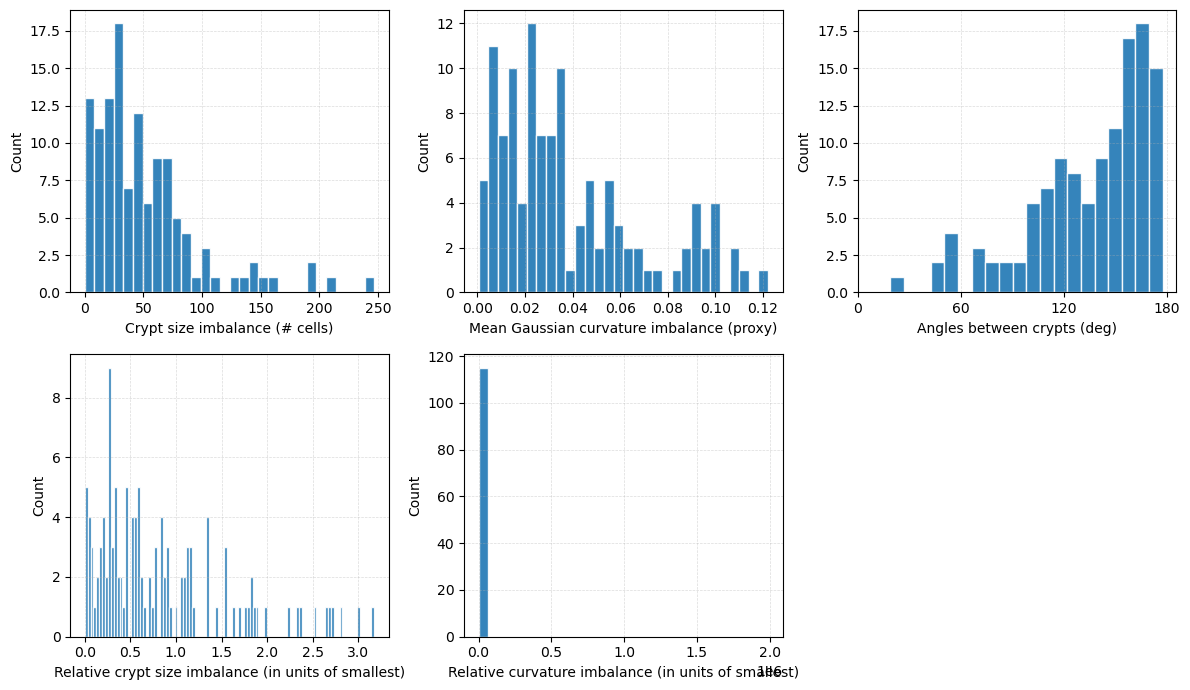

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def hks_to_curv_proxy_single_t(hks_col, t, d=2):
    """
    Convert a single HKS column (N,) at diffusion time t to a curvature-like target:
      Y_t = (6/t) * [ (4πt)^{d/2} * HKS_t - 1 ]  ~  Gaussian curvature
    Returns float32 (N,).
    """
    h = np.asarray(hks_col, dtype=np.float64).reshape(-1)
    t = float(t)
    Y = (6.0 / t) * ((4.0 * np.pi * t) ** (d / 2.0) * h - 1.0)
    return Y.astype(np.float32)

def as_patch_list(x):
    """Normalize to list[set[int]]: None -> [], set -> [set], list/tuple -> list of sets."""
    if x is None:
        return []
    if isinstance(x, set):
        return [x]
    if isinstance(x, (list, tuple)):
        return [set(p) for p in x if p is not None and len(p) > 0]
    return []

size_diff = []
curv_diff = []
size_diff_rel = []
curv_diff_rel = []
angles_deg = []  # pairwise angles between crypts (degrees)

for tp, d in results.items():
    crypts_all = d.get("crypts_all", [])
    villus_all = d.get("villus_all", [])
    Gs         = d.get("cell_graphs_all", [])

    if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()
    if isinstance(villus_all, np.ndarray): villus_all = villus_all.tolist()

    if not Gs:
        continue

    for i in range(len(Gs)):
        G = Gs[i]
        if G is None:
            continue

        crypt_patches  = as_patch_list(crypts_all[i] if i < len(crypts_all) else None)
        villus_patches = as_patch_list(villus_all[i] if i < len(villus_all) else None)

        if not villus_patches:
            continue  # need villus to define rays
        villus_patch = villus_patches[0]  # you filtered to exactly one villus earlier

        num_crypts = len(crypt_patches)
        if num_crypts < 2:
            continue

        n_cells = G.number_of_nodes()

        # --- per-cell HKS and centroids from graph nodes ---
        # HKS_cell: (N_cells, T)
        HKS_cell = np.vstack([np.asarray(G.nodes[n]["hks"], dtype=float) for n in range(n_cells)])

        # centroids: (N_cells, 3)
        C = np.vstack([np.asarray(G.nodes[n]["centroid"], dtype=float) for n in range(n_cells)])

        # --- size/curvature diffs ---
        crypt_sizes = np.zeros(num_crypts, dtype=float)
        crypt_mean_curv = np.zeros(num_crypts, dtype=float)

        for j, patch in enumerate(crypt_patches):
            idx = np.fromiter(patch, dtype=int)
            if idx.size == 0:
                crypt_sizes[j] = np.nan
                crypt_mean_curv[j] = np.nan
                continue

            curv_crypt = hks_to_curv_proxy_single_t(HKS_cell[idx, 0], 1.0)
            crypt_sizes[j] = float(idx.size)
            crypt_mean_curv[j] = float(np.nanmean(curv_crypt))

        # drop if any crypt invalid
        if not np.all(np.isfinite(crypt_sizes)) or not np.all(np.isfinite(crypt_mean_curv)):
            continue

        # absolute diffs (upper triangle)
        diff = crypt_sizes[:, None] - crypt_sizes[None, :]
        size_diff.append(diff[np.triu_indices(num_crypts, k=1)])

        min_size = float(np.min(crypt_sizes))
        size_diff_rel.append(diff[np.triu_indices(num_crypts, k=1)] / max(min_size, 1e-8))

        diff = crypt_mean_curv[:, None] - crypt_mean_curv[None, :]
        curv_diff.append(diff[np.triu_indices(num_crypts, k=1)])

        min_curv = float(np.min(crypt_mean_curv))
        curv_diff_rel.append(diff[np.triu_indices(num_crypts, k=1)] / max(min_curv, 1e-8))

        # --- ANGLES: villus→crypt rays using per-cell centroids ---
        v_idx = np.fromiter(villus_patch, dtype=int)
        if v_idx.size == 0:
            continue
        v_com = np.nanmean(C[v_idx, :], axis=0)

        rays = []
        for patch in crypt_patches:
            idx = np.fromiter(patch, dtype=int)
            if idx.size == 0:
                rays.append(np.array([np.nan, np.nan, np.nan]))
                continue
            c_com = np.nanmean(C[idx, :], axis=0)
            rays.append(c_com - v_com)

        rays = np.asarray(rays, dtype=float)  # (num_crypts, 3)
        norms = np.linalg.norm(rays, axis=1)
        valid = np.isfinite(norms) & (norms > 0)

        if np.count_nonzero(valid) < 2:
            continue

        Rn = np.zeros_like(rays)
        Rn[valid] = rays[valid] / norms[valid, None]

        cosM = np.clip(Rn @ Rn.T, -1.0, 1.0)
        theta = np.degrees(np.arccos(cosM))
        angles_deg.append(theta[np.triu_indices(num_crypts, k=1)])

# concatenate safely
def _cat_or_empty(lst):
    return np.concatenate(lst) if len(lst) else np.array([], dtype=float)

size_diff = np.abs(_cat_or_empty(size_diff))
curv_diff = np.abs(_cat_or_empty(curv_diff))
size_diff_rel = np.abs(_cat_or_empty(size_diff_rel))
curv_diff_rel = np.abs(_cat_or_empty(curv_diff_rel))
angles_deg = _cat_or_empty(angles_deg)

plt.figure(figsize=(12, 7))

plt.subplot(2, 3, 1)
plt.hist(size_diff, bins=30, edgecolor="white", alpha=0.9)
plt.xlabel("Crypt size imbalance (# cells)")
plt.ylabel("Count")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
plt.tight_layout()

plt.subplot(2, 3, 2)
if curv_diff.size:
    lo, hi = np.percentile(curv_diff, [0, 95])
    plt.hist(curv_diff, bins=30, range=(lo, hi), edgecolor="white", alpha=0.9)
else:
    plt.hist(curv_diff, bins=30, edgecolor="white", alpha=0.9)
plt.xlabel("Mean Gaussian curvature imbalance (proxy)")
plt.ylabel("Count")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
plt.tight_layout()

plt.subplot(2, 3, 3)
plt.hist(angles_deg, bins=20, edgecolor="white", alpha=0.9)
plt.xticks([0, 60, 120, 180])
plt.xlabel("Angles between crypts (deg)")
plt.ylabel("Count")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
plt.tight_layout()

plt.subplot(2, 3, 4)
plt.hist(size_diff_rel, bins=100, edgecolor="white", alpha=0.9)
plt.xlabel("Relative crypt size imbalance (in units of smallest)")
plt.ylabel("Count")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
plt.tight_layout()

plt.subplot(2, 3, 5)
if curv_diff_rel.size:
    lo, hi = np.percentile(curv_diff_rel, [0, 95])
    plt.hist(curv_diff_rel, bins=30, range=(lo, hi), edgecolor="white", alpha=0.9)
else:
    plt.hist(curv_diff_rel, bins=30, edgecolor="white", alpha=0.9)
plt.xlabel("Relative curvature imbalance (in units of smallest)")
plt.ylabel("Count")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
plt.tight_layout()

plt.show()


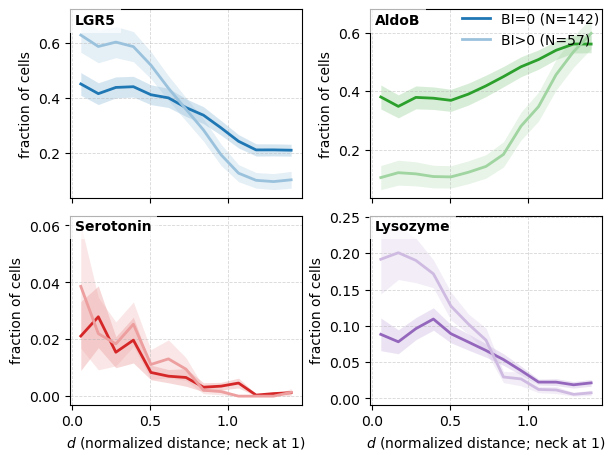

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Settings
# ============================================================
target_markers = ["LGR5", "AldoB", "Serotonin", "Lysozyme"]
target_indices = [marker_names.index(m) for m in target_markers]

k = 6  # coarsen factor (required)

# Base colors (matplotlib will accept these hex strings)
marker_colors = {
    "LGR5":      "#1f77b4",
    "AldoB":     "#2ca02c",
    "Serotonin": "#d62728",
    "Lysozyme":  "#9467bd",
}

# Simple "lighter" helper (no extra deps)
def lighten_color(rgb_or_hex, amount=0.55):
    """
    Mix color with white. amount=0 -> original, amount=1 -> white.
    """
    import matplotlib.colors as mcolors
    c = np.array(mcolors.to_rgb(rgb_or_hex))
    return tuple((1 - amount) * c + amount * np.ones(3))

# ============================================================
# Coarsen helper (your function)
# ============================================================
def coarsen_bins(bin_centers, counts, k):
    """
    Combine bins by summing every k consecutive bins.

    bin_centers: (n_bins,)
    counts: (..., n_bins)
    k: int, number of bins to combine
    """
    if k <= 1:
        return bin_centers, counts

    n_bins = bin_centers.shape[0]
    n_coarse = n_bins // k
    trunc = n_coarse * k

    bin_centers_trunc = bin_centers[:trunc]
    counts_trunc = counts[..., :trunc]

    new_shape = counts_trunc.shape[:-1] + (n_coarse, k)
    counts_block = counts_trunc.reshape(new_shape)
    counts_coarse = counts_block.sum(axis=-1)

    bin_centers_block = bin_centers_trunc.reshape(n_coarse, k)
    bin_centers_coarse = bin_centers_block.mean(axis=1)

    return bin_centers_coarse, counts_coarse

# ============================================================
# Flatten crypt-binned profiles (no recomputation)
# ============================================================
pos_flat = np.concatenate(marker_pos_counts_all, axis=0).astype(float)   # (Ncrypt, M, n_bins)
tot_flat = np.concatenate(marker_cell_counts_all, axis=0).astype(float)  # (Ncrypt, n_bins)
BI_flat  = np.concatenate(BI_all, axis=0).astype(float)                  # (Ncrypt,)

# BI groups
m_bi0   = (BI_flat == 0.0)
m_bipos = (BI_flat > 0.0)

# ============================================================
# Coarsen POS and TOT FIRST, then build fractions
# ============================================================
x_coarse, pos_flat_c = coarsen_bins(bin_centers, pos_flat, k)   # pos_flat_c: (Ncrypt, M, n_bins_c)
_,        tot_flat_c = coarsen_bins(bin_centers, tot_flat, k)   # tot_flat_c: (Ncrypt, n_bins_c)

frac_flat_c = pos_flat_c / np.maximum(tot_flat_c[:, None, :], 1.0)  # (Ncrypt, M, n_bins_c)

# Mean + SEM across crypts (per marker, per bin)
def mean_and_sem(frac_group):  # (N, n_bins_c)
    mu = np.nanmean(frac_group, axis=0)
    sd = np.nanstd(frac_group, axis=0, ddof=1)
    n  = np.sum(np.isfinite(frac_group), axis=0)
    se = sd / np.sqrt(np.maximum(n, 1))
    return mu, se

# ============================================================
# Plot: 2x2 grid, solid lines, darker vs lighter hue
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(6, 4.5), sharex=True, constrained_layout=True)
axes = axes.ravel()

for ax, m_idx in zip(axes, target_indices):
    marker_name = marker_names[m_idx]
    base = marker_colors.get(marker_name, "#1f77b4")
    dark = base
    light = lighten_color(base, amount=0.55)

    # BI=0 (dark)
    mu0, se0 = mean_and_sem(frac_flat_c[m_bi0, m_idx, :])
    ax.fill_between(x_coarse, mu0 - se0, mu0 + se0, color=dark, alpha=0.18, linewidth=0)
    ax.plot(x_coarse, mu0, color=dark, linewidth=2.0, label=f"BI=0 (N={int(m_bi0.sum())})")

    # BI>0 (light)
    mu1, se1 = mean_and_sem(frac_flat_c[m_bipos, m_idx, :])
    ax.fill_between(x_coarse, mu1 - se1, mu1 + se1, color=light, alpha=0.25, linewidth=0)
    ax.plot(x_coarse, mu1, color=light, linewidth=2.0, label=f"BI>0 (N={int(m_bipos.sum())})")

    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_ylabel("fraction of cells")

    ax.text(
        0.02, 0.98,
        marker_name,
        transform=ax.transAxes,
        ha="left", va="top",
        fontweight="bold", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7)
    )

# Shared x label only on bottom row
for ax in axes[-2:]:
    ax.set_xlabel(r"$d$ (normalized distance; neck at 1)")

# Single legend (use first axis handles)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", frameon=False)


# plt.savefig("crypt_enrichment.svg", format="svg")

plt.show()
